Goal
- Determine which (subjective) textual characteristics make some deals garner more applications than others
    - Specific focus on mutable characteristics: that which we can change about the text

# Raw deals

In [72]:
import pandas as pd
import numpy as np
import src.paths

In [73]:
df_deals = pd.read_parquet(
    src.paths.PROCESSED_DATA_DIR / "BARTER_DEALS_MODEL_READY.parquet")

## Reconsolidate product categories

In [74]:
def clean_tags(tag_set):
    # If the cell is actually just NaN (not a set), return it as is
    if pd.isna(tag_set) and not isinstance(tag_set, (set, list)):
        return np.nan

    # Keep items that are NOT 'UGC' and NOT NaN
    cleaned = {item for item in tag_set if item != 'UGC' and not pd.isna(item)}

    # If the set is now empty (e.g., it was just {'UGC'} or {'UGC', nan}), return NaN
    return cleaned if len(cleaned) > 0 else np.nan


# Apply the cleaning function
df_deals['content_types_set'] = df_deals['content_types_set'].apply(set)
df_deals['content_types_clean'] = df_deals['content_types_set'].apply(
    clean_tags)

In [75]:
import pandas as pd
import numpy as np
import re

# Define the exact word boundaries (\b) so "mother" doesn't trigger on "smother"
# WARNING: The Dutch word "kind" overlaps with the English word "kind" (e.g., "be kind to your skin").
# If you have a lot of English Beauty deals, you might want to replace '\bkind\b' with '\bkindje\b' or '\bkinderen\b' to avoid false positives.
mom_keywords = [
    r'\bbaby\b', r'\bchildren\b', r'\bkids\b', r'\bkind\b', r'\bkinderen\b',
    r'\bparents\b', r'\bvader\b', r'\bmoeder\b', r'\bfather\b', r'\bmother\b',
    r'\bouders\b', r'\btoddler\b', r'\bzwanger\b', r'\bpregnant\b'
]

# Compile the regex pattern for speed
mom_regex = re.compile('|'.join(mom_keywords), re.IGNORECASE)


def assign_macro_category(row):
    tag_set = row['content_types_set']
    deal_type = str(row.get('deal_type', 'unknown')).lower()

    # Combine title and description to search for keywords (adjust column names as needed)
    text_content = str(row.get('deal_text', '')) + " " + \
        str(row.get('description', ''))

    # Handle floats, NaNs, or empty sets
    if not isinstance(tag_set, (set, list)) or pd.isna(tag_set):
        return 'Uncategorized'

    cleaned_tags = {str(t) for t in tag_set if str(
        t).lower() not in ['ugc', 'nan', 'none']}
    if not cleaned_tags:
        return 'Uncategorized'

    # --- 1. The Validated Family & Parenting Category ---
    if 'Mom' in cleaned_tags:
        if cleaned_tags == {'Mom'}:
            return 'Family & Parenting'
        # Check if the text actually contains parenting keywords
        elif mom_regex.search(text_content):
            return 'Family & Parenting'
        else:
            # If it's a fake "Mom" deal, remove the tag so it falls into its true category below
            cleaned_tags.remove('Mom')

    # If a deal didn't have the 'Mom' tag but heavily features the keywords,
    # you can uncomment the next two lines to forcibly categorize it as Parenting:
    # elif mom_regex.search(text_content):
    #     return 'Family & Parenting'

    # If removing 'Mom' left the set empty, it's basically uncategorized
    if not cleaned_tags:
        return 'Other'

    if 'Animals' in cleaned_tags:
        return 'Animals'

    # --- 3. Split Food & Beverage Logic ---
    has_food_drink = any(tag in cleaned_tags for tag in [
                         'Food', 'Drinks', 'Vegan'])
    has_cooking = 'Cooking' in cleaned_tags

    if has_cooking or (has_food_drink and deal_type == 'online'):
        return 'Home Cooking & CPG'
    elif has_food_drink and deal_type == 'physical':
        return 'Dining & Hospitality'
    elif has_food_drink:
        return 'Food & Beverage (Unknown Type)'

    # --- 4. Beauty ---
    if 'Beauty' in cleaned_tags:
        return 'Beauty'

    # --- 5. Fashion ---
    if 'Fashion' in cleaned_tags:
        return 'Fashion'

    # --- 6. Split Entertainment & Experiences Logic ---
    ent_tags = ['Entertainment', 'Experiences', 'Nightlife',
                'Movie', 'Music', 'Travel', 'Activities', 'Photography']
    has_ent = any(tag in cleaned_tags for tag in ent_tags)

    if has_ent and deal_type == 'physical':
        return 'In-Person Experiences'
    elif has_ent and deal_type == 'online':
        return 'Digital Entertainment'
    elif has_ent:
        return 'Entertainment & Experiences (Unknown Type)'

    # --- 7. Lifestyle & Home (The Catch-all) ---
    if any(tag in cleaned_tags for tag in ['Lifestyle', 'Luxury']):
        return 'Lifestyle & Home'

        # --- 2. Tech & Male-Skewed Niche ---
    if any(tag in cleaned_tags for tag in ['Gaming', 'Tech', 'Cars', 'Finance', 'Sport']):
        return 'Tech & Niche'

    return 'Other'


# Apply the new validated function
df_deals['macro_category'] = df_deals.apply(assign_macro_category, axis=1)

Recompute competitor density

In [ ]:
def compute_competitor_density(input_df):
    df = input_df.copy()
    # Count deals per category per day
    df['date'] = df['created_at'].dt.date
    daily_counts = df.groupby(['date', 'consolidated_categories']).size(
    ).reset_index(name='category_daily_count')

    # Merge back (subtract 1 so the deal doesn't count itself)
    df = df.merge(daily_counts, on=['date', 'consolidated_categories'])
    df['competitor_density'] = df['category_daily_count'] - 1

    return df

## Validation

In [76]:
df_deals['macro_category'].value_counts()

macro_category
Home Cooking & CPG       705
Beauty                   551
Fashion                  409
Digital Entertainment    371
Dining & Hospitality     264
Lifestyle & Home         247
Family & Parenting       172
Animals                  133
In-Person Experiences    127
Tech & Niche              91
Uncategorized             56
Name: count, dtype: int64

In [77]:
# Convert the sets to sorted strings so identical sets group together properly
df_deals['content_types_str'] = df_deals['content_types_set'].apply(
    lambda x: ', '.join(
        sorted([str(i) for i in x if str(i).lower() not in ['nan', 'none']]))
    if isinstance(x, (set, list)) else 'Uncategorized'
)

# Create the summary suite
validation_suite = df_deals.groupby(['macro_category', 'content_types_str']).agg(
    deal_count=('apps_after_7_days', 'count'),
    avg_apps=('apps_after_7_days', 'mean')
).reset_index()

# Sort to see the largest categories first
validation_suite = validation_suite.sort_values(
    by=['macro_category', 'deal_count'], ascending=[True, False])

# Display the suite (if using Jupyter, just run the variable name)
display(validation_suite)

,macro_category,content_types_str,deal_count,avg_apps
34,Animals,Animals,33,8.242424
1,Animals,"Activities, Animals, Beauty, Cars, Cooking, Dr...",8,4.875000
72,Animals,"Animals, UGC",5,7.800000
33,Animals,"Activities, Animals, Sport",4,1.750000
69,Animals,"Animals, Luxury",3,7.666667
...,...,...,...,...
1121,Tech & Niche,"Gaming, Tech",1,3.000000
1123,Tech & Niche,"Mom, Tech",1,0.000000
1126,Tech & Niche,"Sport, UGC",1,4.000000
1130,Uncategorized,UGC,55,11.581818


# Main analysis

## Load data

In [ ]:
# Setup
import yaml
from src.general_analysis.engine import AnalysisEnvironment
from src.barter.regression_models import create_regression_runner
from src.utils import interactive_regression_results_selector

import pandas as pd
import numpy as np
import statsmodels.api as sm

In [3]:
env = AnalysisEnvironment(active_analysis='barter_deals')

# Load everything
final_df, og_df = env.load_data()
pm, prompt_map = env.load_prompts(prompt_subfolder='sandbox/BARTER_DEALS')

Loading files for analysis barter_deals
🐢 Running full processing pipeline...
Results dir: C:\Users\Wouter Barter\Documents\AI_thesis\results\sandbox\BARTER_DEALS
input_data_path: C:\Users\Wouter Barter\Documents\AI_thesis\data\processed\BARTER_DEALS_MODEL_READY.parquet
Loading evaluations...
Filtered to 13 folders based on allowed_prompt_ids.
⚡ Fast-loading compiled folder: dataset-barter_deals_model-google-gemma-4-E2B-it_prompt-698a82f5d8a3_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_model-google-gemma-4-E2B-it_prompt-6faa8a8b031c_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_model-google-gemma-4-E2B-it_prompt-f162d59256cc_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_model-meta-llama-Llama-3.2-3B-Instruct_prompt-698a82f5d8a3_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_model-meta-llama-Llama-3.2-3B-Instruct_prompt-6faa8a8b031c_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_mode

C:\Users\Wouter Barter\Documents\AI_thesis\src\data_processing.py:549: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.loc[:, 'first_content_type'] = final_df.content_types.apply(


USE PROCESSED INPUT DATA = True
PromptManager initialized with folder: ..\prompts\PromptSuites\sandbox\BARTER_DEALS
Scanning 33 suites from ..\prompts\PromptSuites\sandbox\BARTER_DEALS...
Loaded 33 PromptSuites


In [ ]:
import re
import html
import pandas as pd


def clean_html_text(text):
    if pd.isna(text):
        return ""

    # Cast to string just in case
    text = str(text)

    # 1. Unescape ALL HTML entities (&nbsp;, &amp;, etc.)
    text = html.unescape(text)

    # 2. Intelligently map structural HTML tags to newlines
    # This catches <br>, <p>, </div>, <li>, etc., and turns them into \n
    text = re.sub(
        r'<(br\s*/?|/?p|/?div|/?li|/?ul|/?ol|/?h[1-6])[^>]*>', '\n', text, flags=re.IGNORECASE)

    # 3. Replace any remaining non-structural HTML tags (like <b>, <span>, <a>) with a space
    text = re.sub(r'<[^>]+>', ' ', text)

    # 4. Clean up horizontal whitespace ONLY (spaces, tabs) without killing newlines
    # [^\S\n] means "match any whitespace character EXCEPT a newline"
    text = re.sub(r'[^\S\n]+', ' ', text)

    # 5. Compress excessive newlines (e.g., turn 3+ blank lines into just 2)
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text.strip()


# Apply to your columns
for col in ['deal_title', 'deal_text', 'creators_requirement']:
    og_df[f'clean_{col}'] = og_df[col].apply(clean_html_text)

# Recalculate word counts on the CLEANED text
og_df['requirements_word_count'] = og_df['clean_creators_requirement'].str.split(
).str.len().fillna(0)

In [ ]:
# Recalculate word counts on the CLEANED text
og_df['requirements_word_count'] = og_df['clean_creators_requirement'].str.split(
).str.len().fillna(0)

In [12]:
import pandas as pd

# Expand column width so you can actually read the before-and-after in the notebook
pd.set_option('display.max_colwidth', None)

cols_to_check = ['deal_title', 'deal_text', 'creators_requirement']

for col in cols_to_check:
    clean_col = f'clean_{col}'

    # Create a mask where the original (with NaNs filled) doesn't match the cleaned version
    # We also strip the original just in case the only difference was leading/trailing spaces
    mask = (og_df[col].fillna("").astype(str).str.strip() != og_df[clean_col])

    changed_rows = og_df[mask]

    print(f"\n{'='*50}")
    print(f"COLUMN: {col}")
    print(f"Total rows changed: {len(changed_rows)}")
    print(f"{'='*50}")

    if len(changed_rows) > 0:
        # Randomly sample 5 changed rows to get a good variety (or use .head(5))
        # sample_size = min(10, len(changed_rows))
        # display(changed_rows[[col, clean_col]].sample(sample_size))
        display(
            changed_rows[[col, clean_col, 'applicants_applications_count']])


# Reset column width to default when you are done inspecting
# pd.reset_option('display.max_colwidth')


COLUMN: deal_title
Total rows changed: 83


,deal_title,clean_deal_title,applicants_applications_count
3101,"Volledig Gezondheidsonderzoek t.v.w. 199,- euro!","Volledig Gezondheidsonderzoek t.v.w. 199,- euro!",35
3104,"Stoomreiniger GRATIS testen t.w.v. € 49,95","Stoomreiniger GRATIS testen t.w.v. € 49,95",89
3335,250 € Geschenkgutschein,250 € Geschenkgutschein,3
3336,500 € Geschenkgutschein,500 € Geschenkgutschein,4
3501,500 € Geschenkgutschein (Gift Card),500 € Geschenkgutschein (Gift Card),9
...,...,...,...
6682,🍄 Nourish from within – Shiitake + €50 credit,🍄 Nourish from within – Shiitake + €50 credit,6
6683,🍄 Cordyceps as a daily routine + €50 credit,🍄 Cordyceps as a daily routine + €50 credit,6
6699,💖 Bestelle deinen Einkauf für 100 €,💖 Bestelle deinen Einkauf für 100 €,77
6745,✨👶 Natalis – Maternity Essentials & Care,✨👶 Natalis – Maternity Essentials & Care,26



COLUMN: deal_text
Total rows changed: 851


,deal_text,clean_deal_text,applicants_applications_count
3093,"Je krijgt exclusief het e‑book (4 eiwitrijke weekmenu’s, 90+ frisse recepten). Vertel dat het fysieke boek 8mei dropt en roep je volgers op naar onze website te gaan. Wij vragen één Instagram Reel of TikTok + 1 Story.\n\nWie is PuurFiguur?\nPuurFiguur is een Nederlands voedingsplatform dat al meer dan 100.000 deelnemers hielp om op een gezonde, haalbare manier af te vallen. De methode draait om volwaardige, onbewerkte ingrediënten, praktische weekmenu’s en nul hongergevoel. Elk boek vertaalt die aanpak naar een specifiek doel (vegetarisch, zomer‑shape, complete afslankreis).\n\nWaarom met ons samenwerken?\nHealth‑content scoort structureel hoge engagement en blijft door algoritmes worden beloond. Door samen te werken met PuurFiguur lever je relevante, waardevolle posts waarmee je jouw bereik en geloofwaardigheid in de wellness‑hoek vergroot.","Je krijgt exclusief het e‑book (4 eiwitrijke weekmenu’s, 90+ frisse recepten). Vertel dat het fysieke boek 8mei dropt en roep je volgers op naar onze website te gaan. Wij vragen één Instagram Reel of TikTok + 1 Story.\n\nWie is PuurFiguur?\nPuurFiguur is een Nederlands voedingsplatform dat al meer dan 100.000 deelnemers hielp om op een gezonde, haalbare manier af te vallen. De methode draait om volwaardige, onbewerkte ingrediënten, praktische weekmenu’s en nul hongergevoel. Elk boek vertaalt die aanpak naar een specifiek doel (vegetarisch, zomer‑shape, complete afslankreis).\n\nWaarom met ons samenwerken?\nHealth‑content scoort structureel hoge engagement en blijft door algoritmes worden beloond. Door samen te werken met PuurFiguur lever je relevante, waardevolle posts waarmee je jouw bereik en geloofwaardigheid in de wellness‑hoek vergroot.",3
3094,"Ben jij gek op escape rooms, dol op avontuur, en straalt jouw enthousiasme door het scherm heen? \nDan ben jij misschien wel de influencer die we zoeken! 🕵️‍♀️🔐\n\nEscape World zoekt creatieve contentmakers die één van onze kamers willen beleven in ruil voor toffe content! We hebben vestigingen in Amsterdam, Hoofddorp, Tilburg, Utrecht en Zandvoort \n\nWat jij krijgt:\n🧩 Een gratis escape room ervaring voor jou + maximaal vijf medespelers\n📣 Een leuke samenwerking waarbij we jouw content delen via onze kanalen (met verwijzing naar jouw profiel)\n","Ben jij gek op escape rooms, dol op avontuur, en straalt jouw enthousiasme door het scherm heen? \nDan ben jij misschien wel de influencer die we zoeken! 🕵️‍♀️🔐\n\nEscape World zoekt creatieve contentmakers die één van onze kamers willen beleven in ruil voor toffe content! We hebben vestigingen in Amsterdam, Hoofddorp, Tilburg, Utrecht en Zandvoort \n\nWat jij krijgt:\n🧩 Een gratis escape room ervaring voor jou + maximaal vijf medespelers\n📣 Een leuke samenwerking waarbij we jouw content delen via onze kanalen (met verwijzing naar jouw profiel)",41
3110,Tuesday 6 may we are launching our new special: a Matcha peach latte. (homemade peach puree)\n\nCome by and be the first to try!!\n\nWhat you get:\n- 2 matcha peach latte\n- 1 pastry\n\n,Tuesday 6 may we are launching our new special: a Matcha peach latte. (homemade peach puree)\n\nCome by and be the first to try!!\n\nWhat you get:\n- 2 matcha peach latte\n- 1 pastry,14
3117,We leveren een bouwlamp op zonen energie in de kleur geel met als tegenprestatie 2 UGC-filmpjes van de bouwlamp\nHet is de bedoeling dat de filmpjes de unieke eigenschappen van de bouwlamp in beeld brengen. Een moderne strakke uitstraling en het multifunctionele gebruik van de bouwlamp.\n,We leveren een bouwlamp op zonen energie in de kleur geel met als tegenprestatie 2 UGC-filmpjes van de bouwlamp\nHet is de bedoeling dat de filmpjes de unieke eigenschappen van de bouwlamp in beeld brengen. Een moderne strakke uitstraling en het multifunctionele gebruik van de bouwlamp.,4
3118,We leveren een foam roller set met als tegenprestatie 2 UGC-filmpjes van de foam roller set Het is de bedoeling dat de filmpjes de unieke ei


COLUMN: creators_requirement
Total rows changed: 911


,creators_requirement,clean_creators_requirement,applicants_applications_count
3083,"We need instagram Reels, showcasing and reviewing the product. Also test the product and see how your skin, mood and energy changes.","We need instagram Reels, showcasing and reviewing the product. Also test the product and see how your skin, mood and energy changes.",10
3085,"2 video's. Bijvoorbeeld 1 hoe een fitting werkt (samen stoffen kiezen, pak samenstellen en het opmeten) en 1 video wanneer het pak klaar is. Er is veel ruimte voor eigen inbreng en creatieve vrijheid.\nDe video's mogen ook door Moneres gebruikt worden in instagram ads.\nPost op Instagram.\nTag @moneresofficial","2 video's. Bijvoorbeeld 1 hoe een fitting werkt (samen stoffen kiezen, pak samenstellen en het opmeten) en 1 video wanneer het pak klaar is. Er is veel ruimte voor eigen inbreng en creatieve vrijheid.\nDe video's mogen ook door Moneres gebruikt worden in instagram ads.\nPost op Instagram.\nTag @moneresofficial",21
3088,"Hoogwaardige content (zoals een styled shoot, Instagram posts, Reels, behind-the-scenes) die wij ook mogen hergebruiken in advertenties etc.\nAlles valt nog te bespreken van eventuele extra's die je wenst.\nPosten op instagram en @moneresofficial taggen.","Hoogwaardige content (zoals een styled shoot, Instagram posts, Reels, behind-the-scenes) die wij ook mogen hergebruiken in advertenties etc.\nAlles valt nog te bespreken van eventuele extra's die je wenst.\nPosten op instagram en @moneresofficial taggen.",4
3093,"Houd de Reel/TikTok rond 30‑60 sec met zomerse visuals (heldere kleuren, buitenlicht).\n\nHighlight één recept waar jij naar uitkijkt: dat maakt het persoonlijk.\n\nPlaats je inschrijflink in de Story‑linksticker of TikTok‑bio en verwijs ernaar in de video.\n\nTag @puurfiguurnl (insta) en @puurfiguur (tiktok) in elke post zodat we snel kunnen reposten.\n\nDrie korte clips (≤ 15 sec) zijn ideaal voor onze advertenties; handig om gelijk mee te leveren.\n\nBij tevredenheid kunnen we na de lancering ook praten over een speciale kortingscode voor jouw volgers.","Houd de Reel/TikTok rond 30‑60 sec met zomerse visuals (heldere kleuren, buitenlicht).\n\nHighlight één recept waar jij naar uitkijkt: dat maakt het persoonlijk.\n\nPlaats je inschrijflink in de Story‑linksticker of TikTok‑bio en verwijs ernaar in de video.\n\nTag @puurfiguurnl (insta) en @puurfiguur (tiktok) in elke post zodat we snel kunnen reposten.\n\nDrie korte clips (≤ 15 sec) zijn ideaal voor onze advertenties; handig om gelijk mee te leveren.\n\nBij tevredenheid kunnen we na de lancering ook praten over een speciale kortingscode voor jouw volgers.",3
3100,"Influencers will receive a discount code to purchase the product, followed by a full refund of the price paid once the agreed content has been delivered.\nContent Requirements:\n1x Instagram Reel/TikTok\n1x Instagram Story\n\n\nTag @amoreargento in both posts (@amoreargentojewellery on TikTok)\n\n\nUse the hashtag #AmoreArgento\n\n\nContent must be shared within 7 days of receiving the product\nWe’re specifically looking for:\nGRWM (Get Ready With Me) style videos where the necklace is styled with your outfit and discussed as part of your look\n\n\nOutfit of the Day (OOTD) clips where the necklace is worn and shown in detail, with a brief mention of its features\n\n\nJewellery layering tutorials or styling tips featuring the necklace\n\n\nVoiceovers or captions highlighting that the piece is “handmade in the UK” and features “real coloured gemstones”\n\n\nPlease ensure the necklace is visibly worn and the content communicates its elegant design, June birthstone sparkle, and premium craftsmanship.\n\n\n\nThis collaboration aims to highlight Amore Argento’s high-quality jewellery through authentic and engaging lifestyle content.\nIf this aligns with your audience and content style, we look forward to collaborating.\n","Influencers will receive a discount code to purchase the product, followed by a full refund of the price pai

In [6]:
final_df['log_input_length'] = np.log(final_df['input_length'])
final_df['log_title_word_count'] = np.log(final_df['title_word_count'])
final_df['log_text_word_count'] = np.log(final_df['text_word_count'])

final_df['requirements_word_count'] = final_df['creators_requirement'].str.split(
).str.len().fillna(0)
final_df['log_requirements_word_count'] = np.log(
    final_df['requirements_word_count'])
final_df['total_deal_word_count'] = final_df['title_word_count'] + \
    final_df['text_word_count'] + final_df['requirements_word_count']
final_df['log_total_deal_word_count'] = np.log(
    final_df['total_deal_word_count'])

final_df['requirements_char_count'] = final_df['creators_requirement'].apply(
    len)
final_df['log_requirements_char_count'] = np.log(
    final_df['requirements_char_count'])

In [7]:
# og_df['log_input_length'] = np.log(og_df['input_length'])
og_df['log_title_word_count'] = np.log(og_df['title_word_count'])
og_df['log_text_word_count'] = np.log(og_df['text_word_count'])

og_df['requirements_word_count'] = og_df['creators_requirement'].str.split(
).str.len().fillna(0)
og_df['log_requirements_word_count'] = np.log(og_df['requirements_word_count'])
og_df['total_deal_word_count'] = og_df['title_word_count'] + \
    og_df['text_word_count'] + og_df['requirements_word_count']
og_df['log_total_deal_word_count'] = np.log(og_df['total_deal_word_count'])

og_df['requirements_char_count'] = og_df['creators_requirement'].apply(len)
og_df['log_requirements_char_count'] = np.log(og_df['requirements_char_count'])

## Pre-processing

### Time fixed effects

In [8]:
# Ensure your date column is a datetime object first
# final_df['date_col'] = pd.to_datetime(final_df['created_at'])

# Create Year-Month (Format: "2025-01", "2025-02", etc.)
final_df['year_month'] = final_df['created_at'].dt.strftime('%Y-%m')
og_df['year_month'] = og_df['created_at'].dt.strftime('%Y-%m')


# Create Year-Week using ISO standard (Format: "2025-W01", "2025-W02", etc.)
# Note: %G is ISO Year and %V is ISO Week. This prevents weird bugs
# where the first week of January belongs to the last week of the previous year.
final_df['year_week'] = final_df['created_at'].dt.strftime('%G-W%V')
og_df['year_week'] = og_df['created_at'].dt.strftime('%G-W%V')

### Balance datasets

In [9]:
def balance_experimental_df(df, input_id_col='input_id', group_cols=['model_name', 'prompt_id']):
    """
    Balances the dataframe so that every experimental group contains 
    the exact same set of unique input_ids. (Long-format safe)
    """
    print(f"Original rows: {len(df)}")

    # 1. Group by the experimental units and collect the set of input_ids for each
    grouped_ids = df.groupby(group_cols)[input_id_col].apply(set)

    # 2. Find the strict intersection
    common_ids = set.intersection(*grouped_ids.values)

    print(f"Unique input_ids appearing in ALL groups: {len(common_ids)}")

    # 3. Filter the dataframe
    balanced_df = df[df[input_id_col].isin(common_ids)].copy()

    # 4. Final verification (Checking UNIQUE ids, not total rows)
    id_counts = balanced_df.groupby(group_cols)[input_id_col].nunique()
    row_counts = balanced_df.groupby(group_cols).size()

    if id_counts.nunique() == 1:
        print(
            f"✅ Success! All groups now evaluate exactly {id_counts.iloc[0]} unique deals.")
        print("\nRow distribution (Formative prompts will show 3x rows due to sub-dimensions):")
        print(row_counts)
    else:
        print("⚠️ Warning: Balancing failed. Check for duplicate input_ids within groups.")
        print(id_counts)

    return balanced_df, common_ids


# --- EXECUTION ---
final_df_balanced, gold_set_ids = balance_experimental_df(final_df)

og_df_balanced = og_df[og_df['deal_id'].isin(gold_set_ids)].copy()

Original rows: 175000
Unique input_ids appearing in ALL groups: 3125
✅ Success! All groups now evaluate exactly 3125 unique deals.

Row distribution (Formative prompts will show 3x rows due to sub-dimensions):
model_name                        prompt_id   
Qwen/Qwen3-4B-Instruct-2507       698a82f5d8a3     9375
                                  6faa8a8b031c     3125
                                  f162d59256cc    31250
Qwen/Qwen3.5-4B                   698a82f5d8a3     9375
                                  6faa8a8b031c     3125
                                  f162d59256cc    31250
google/gemma-4-E2B-it             698a82f5d8a3     9375
                                  6faa8a8b031c     3125
                                  f162d59256cc    31250
meta-llama/Llama-3.2-3B-Instruct  698a82f5d8a3     9375
                                  6faa8a8b031c     3125
                                  f162d59256cc    31250
dtype: int64


### Macro category: Product categories revised

In [ ]:
import pandas as pd
import numpy as np
import re

# Define the exact word boundaries (\b) so "mother" doesn't trigger on "smother"
# WARNING: The Dutch word "kind" overlaps with the English word "kind" (e.g., "be kind to your skin").
# If you have a lot of English Beauty deals, you might want to replace '\bkind\b' with '\bkindje\b' or '\bkinderen\b' to avoid false positives.
mom_keywords = [
    r'\bbaby\b', r'\bchildren\b', r'\bkids\b', r'\bkind\b', r'\bkinderen\b',
    r'\bparents\b', r'\bvader\b', r'\bmoeder\b', r'\bfather\b', r'\bmother\b',
    r'\bouders\b', r'\btoddler\b', r'\bzwanger\b', r'\bpregnant\b'
]

# Compile the regex pattern for speed
mom_regex = re.compile('|'.join(mom_keywords), re.IGNORECASE)


def assign_macro_category(row):
    tag_set = row['content_types_set']
    deal_type = str(row.get('deal_type', 'unknown')).lower()

    # Combine title and description to search for keywords (adjust column names as needed)
    text_content = str(row.get('deal_text', '')) + " " + \
        str(row.get('description', ''))

    # Handle floats, NaNs, or empty sets
    if not isinstance(tag_set, (set, list)) or pd.isna(tag_set):
        return 'Uncategorized'

    cleaned_tags = {str(t) for t in tag_set if str(
        t).lower() not in ['ugc', 'nan', 'none']}
    if not cleaned_tags:
        return 'Uncategorized'

    # --- 1. The Validated Family & Parenting Category ---
    if 'Mom' in cleaned_tags:
        if cleaned_tags == {'Mom'}:
            return 'Family & Parenting'
        # Check if the text actually contains parenting keywords
        elif mom_regex.search(text_content):
            return 'Family & Parenting'
        else:
            # If it's a fake "Mom" deal, remove the tag so it falls into its true category below
            cleaned_tags.remove('Mom')

    # If a deal didn't have the 'Mom' tag but heavily features the keywords,
    # you can uncomment the next two lines to forcibly categorize it as Parenting:
    # elif mom_regex.search(text_content):
    #     return 'Family & Parenting'

    # If removing 'Mom' left the set empty, it's basically uncategorized
    if not cleaned_tags:
        return 'Other'

    if 'Animals' in cleaned_tags:
        return 'Animals'

    # --- 3. Split Food & Beverage Logic ---
    has_food_drink = any(tag in cleaned_tags for tag in [
                         'Food', 'Drinks', 'Vegan'])
    has_cooking = 'Cooking' in cleaned_tags

    if has_cooking or (has_food_drink and deal_type == 'online'):
        return 'Home Cooking & CPG'
    elif has_food_drink and deal_type == 'physical':
        return 'Dining & Hospitality'
    elif has_food_drink:
        return 'Food & Beverage (Unknown Type)'

    # --- 4. Beauty ---
    if 'Beauty' in cleaned_tags:
        return 'Beauty'

    # --- 5. Fashion ---
    if 'Fashion' in cleaned_tags:
        return 'Fashion'

    # --- 6. Split Entertainment & Experiences Logic ---
    ent_tags = ['Entertainment', 'Experiences', 'Nightlife',
                'Movie', 'Music', 'Travel', 'Activities', 'Photography']
    has_ent = any(tag in cleaned_tags for tag in ent_tags)

    if has_ent and deal_type == 'physical':
        return 'In-Person Experiences'
    elif has_ent and deal_type == 'online':
        return 'Digital Entertainment'
    elif has_ent:
        return 'Entertainment & Experiences (Unknown Type)'

    # --- 7. Lifestyle & Home (The Catch-all) ---
    if any(tag in cleaned_tags for tag in ['Lifestyle', 'Luxury']):
        return 'Lifestyle & Home'

        # --- 2. Tech & Male-Skewed Niche ---
    if any(tag in cleaned_tags for tag in ['Gaming', 'Tech', 'Cars', 'Finance', 'Sport']):
        return 'Tech & Niche'

    return 'Other'


# Apply the new validated function
final_df_balanced['content_types_set'] = final_df_balanced['content_types_set'].apply(
    set)
final_df_balanced['macro_category'] = final_df_balanced.apply(
    assign_macro_category, axis=1)

og_df_balanced['content_types_set'] = og_df_balanced['content_types_set'].apply(
    set)
og_df_balanced['macro_category'] = og_df_balanced.apply(
    assign_macro_category, axis=1)

final_df_balanced = final_df_balanced[final_df_balanced['macro_category']
                                      != 'Uncategorized']
og_df_balanced = og_df_balanced[og_df_balanced['macro_category']
                                != 'Uncategorized']

In [11]:
og_df_balanced.groupby(['date', 'macro_category']).size(
).reset_index(name='category_daily_count')

,date,macro_category,category_daily_count
0,2025-05-01,Animals,1
1,2025-05-01,Beauty,1
2,2025-05-01,Dining & Hospitality,3
3,2025-05-01,Family & Parenting,1
4,2025-05-01,Fashion,4
...,...,...,...
1374,2026-03-09,Dining & Hospitality,1
1375,2026-03-09,Home Cooking & CPG,6
1376,2026-03-09,Lifestyle & Home,1
1377,2026-03-10,Beauty,1


### Competitor density

In [12]:
def compute_competitor_density(input_df, category_col, density_col):
    df = input_df.copy()

    # Extract date if it doesn't already exist
    if 'date' not in df.columns:
        df['date'] = df['created_at'].dt.date

    # Use transform to broadcast the group size back to the original rows, minus 1
    df[density_col] = df.groupby(['date', category_col])[
        'date'].transform('size') - 1

    return df


# Execute
final_df_balanced = compute_competitor_density(
    final_df_balanced, 'macro_category', 'competitor_density_new')
og_df_balanced = compute_competitor_density(
    og_df_balanced, 'macro_category', 'competitor_density_new')

final_df_balanced['log_competitor_density_new'] = np.log1p(
    final_df_balanced['competitor_density_new'])
og_df_balanced['log_competitor_density_new'] = np.log1p(
    og_df_balanced['competitor_density_new'])

final_df_balanced['log_competitor_density'] = np.log1p(
    final_df_balanced['competitor_density'])

### z-standardize 

We need to z-standardize the ratings, to make the coefficients comparable. We saw the because of the truncated scale we work work (1-7), when using the expected value scores on a high-entropy measurement model, the values are pulled towards the mean (See violin plots comparing gemma and qwen). 

New coefficient interpretation:
- "A 1-standard-deviation increase in the AI's rating results in an X% change in creator applications."

In [13]:
import pandas as pd

print("--- 🚀 STANDARDIZING MEASUREMENTS FOR ECONOMETRIC COMPARISON ---")

# 1. Apply the Z-score transformation using groupby and transform
# We use ddof=1 for the sample standard deviation
final_df_balanced['z_mode_rating'] = final_df_balanced.groupby(
    ['model_name', 'prompt_id', 'dimension_name']
)['mode_rating'].transform(lambda x: (x - x.mean()) / x.std(ddof=1))

# 2. Quick Sanity Check
# Let's verify that the means are 0 and standard deviations are 1 for our two main models
sanity_check = final_df_balanced[
    final_df_balanced['model_name'].isin(
        ['Qwen/Qwen3.5-4B', 'google/gemma-4-E2B-it'])
].groupby(['model_name', 'dimension_name'])['z_mode_rating'].agg(['mean', 'std']).round(3).head(10)

print("\nSanity Check: Means should be 0.0, Standard Deviations should be 1.0")
display(sanity_check)

--- 🚀 STANDARDIZING MEASUREMENTS FOR ECONOMETRIC COMPARISON ---

Sanity Check: Means should be 0.0, Standard Deviations should be 1.0


mean  std
model_name      dimension_name                                          
Qwen/Qwen3.5-4B deal_pitch_formative_brand_prestige            -0.0  1.0
                deal_pitch_formative_call_to_action_strength    0.0  1.0
                deal_pitch_formative_creative_restrictiveness   0.0  1.0
                deal_pitch_formative_creator_brand_alignment   -0.0  1.0
                deal_pitch_formative_functional_utility         0.0  1.0
                deal_pitch_formative_perceived_economic_value   0.0  1.0
                deal_pitch_formative_product_universality       0.0  1.0
                deal_pitch_formative_proposition_clarity       -0.0  1.0
                deal_pitch_formative_rhetorical_realism         0.0  1.0
                deal_pitch_formative_workload_volume           -0.0  1.0

In [14]:
import pandas as pd

print("--- 🚀 STANDARDIZING MEASUREMENTS FOR ECONOMETRIC COMPARISON ---")

# 1. Apply the Z-score transformation using groupby and transform
# We use ddof=1 for the sample standard deviation
final_df_balanced['z_mean_rating'] = final_df_balanced.groupby(
    ['model_name', 'prompt_id', 'dimension_name']
)['mean_rating'].transform(lambda x: (x - x.mean()) / x.std(ddof=1))

# 2. Quick Sanity Check
# Let's verify that the means are 0 and standard deviations are 1 for our two main models
sanity_check = final_df_balanced[
    final_df_balanced['model_name'].isin(
        ['Qwen/Qwen3.5-4B', 'google/gemma-4-E2B-it'])
].groupby(['model_name', 'dimension_name'])['z_mean_rating'].agg(['mean', 'std']).round(3).head(10)

print("\nSanity Check: Means should be 0.0, Standard Deviations should be 1.0")
display(sanity_check)

--- 🚀 STANDARDIZING MEASUREMENTS FOR ECONOMETRIC COMPARISON ---

Sanity Check: Means should be 0.0, Standard Deviations should be 1.0


mean  std
model_name      dimension_name                                          
Qwen/Qwen3.5-4B deal_pitch_formative_brand_prestige             0.0  1.0
                deal_pitch_formative_call_to_action_strength   -0.0  1.0
                deal_pitch_formative_creative_restrictiveness  -0.0  1.0
                deal_pitch_formative_creator_brand_alignment    0.0  1.0
                deal_pitch_formative_functional_utility        -0.0  1.0
                deal_pitch_formative_perceived_economic_value   0.0  1.0
                deal_pitch_formative_product_universality      -0.0  1.0
                deal_pitch_formative_proposition_clarity        0.0  1.0
                deal_pitch_formative_rhetorical_realism        -0.0  1.0
                deal_pitch_formative_workload_volume           -0.0  1.0

### "Social media" categorical

In [15]:
import numpy as np
import pandas as pd

print("--- 🚀 OPTIMIZED GREPPING (O(N) on Base Deals) ---")

# 1. Perform string concatenation strictly on the unique base dataframe
combined_text = (
    og_df_balanced['deal_title'].fillna('') + ' ' +
    og_df_balanced['deal_text'].fillna('') + ' ' +
    og_df_balanced['creators_requirement'].fillna('')
).str.lower()

# 2. Extract platforms using regex
platforms = {
    'instagram': r'\b(?:instagram|ig|insta)\b',
    'tiktok': r'\btiktok\b',
    'youtube': r'\b(?:youtube|yt)\b',
    'facebook': r'\b(?:facebook|fb)\b'
}

# We can store these temporarily directly in og_df_balanced
for plat, regex_pattern in platforms.items():
    og_df_balanced[f'req_{plat}'] = combined_text.str.contains(
        regex_pattern, regex=True).astype(int)

# 3. Calculate platform count per deal
og_df_balanced['platform_count'] = og_df_balanced[[
    f'req_{p}' for p in platforms.keys()]].sum(axis=1)

# 4. Bucketing Strategy for Multicollinearity
conditions = [
    (og_df_balanced['req_instagram'] == 1) & (
        og_df_balanced['platform_count'] == 1),
    (og_df_balanced['req_tiktok'] == 1) & (
        og_df_balanced['platform_count'] == 1),
    (og_df_balanced['req_youtube'] == 1) & (
        og_df_balanced['platform_count'] == 1),
    (og_df_balanced['req_instagram'] == 1) & (
        og_df_balanced['req_tiktok'] == 1) & (og_df_balanced['platform_count'] == 2),
    (og_df_balanced['platform_count'] > 1)
]

choices = [
    'Instagram_Only',
    'TikTok_Only',
    'YouTube_Only',
    'IG_and_TikTok',
    'Omnichannel_Complex'
]

og_df_balanced['platform_strategy'] = np.select(
    conditions, choices, default='Unspecified')

print("\nDistribution in Base Data:")
print(og_df_balanced['platform_strategy'].value_counts())

# 5. Broadcast (Merge) back to the long analysis dataframe
print("\n--- 🔗 MERGING BACK TO FINAL DATAFRAME ---")

# We only bring over the column we need to avoid bloating final_df_balanced
merge_cols = ['deal_id', 'platform_strategy']

final_df_balanced = final_df_balanced.merge(
    og_df_balanced[merge_cols],
    on='deal_id',
    how='left'
)

# Optional cleanup: drop the redundant 'deal_id' column if it was copied over during the merge
# if 'deal_id' in final_df_balanced.columns and 'deal_id' != 'input_id':
#     final_df_balanced = final_df_balanced.drop(columns=['deal_id'])

print("Merge complete! 'platform_strategy' is now ready for regression.")

--- 🚀 OPTIMIZED GREPPING (O(N) on Base Deals) ---

Distribution in Base Data:
platform_strategy
IG_and_TikTok          1051
Unspecified             842
TikTok_Only             473
Instagram_Only          437
Omnichannel_Complex     253
YouTube_Only             14
Name: count, dtype: int64

--- 🔗 MERGING BACK TO FINAL DATAFRAME ---
Merge complete! 'platform_strategy' is now ready for regression.


## Diagnostics

### Correlations

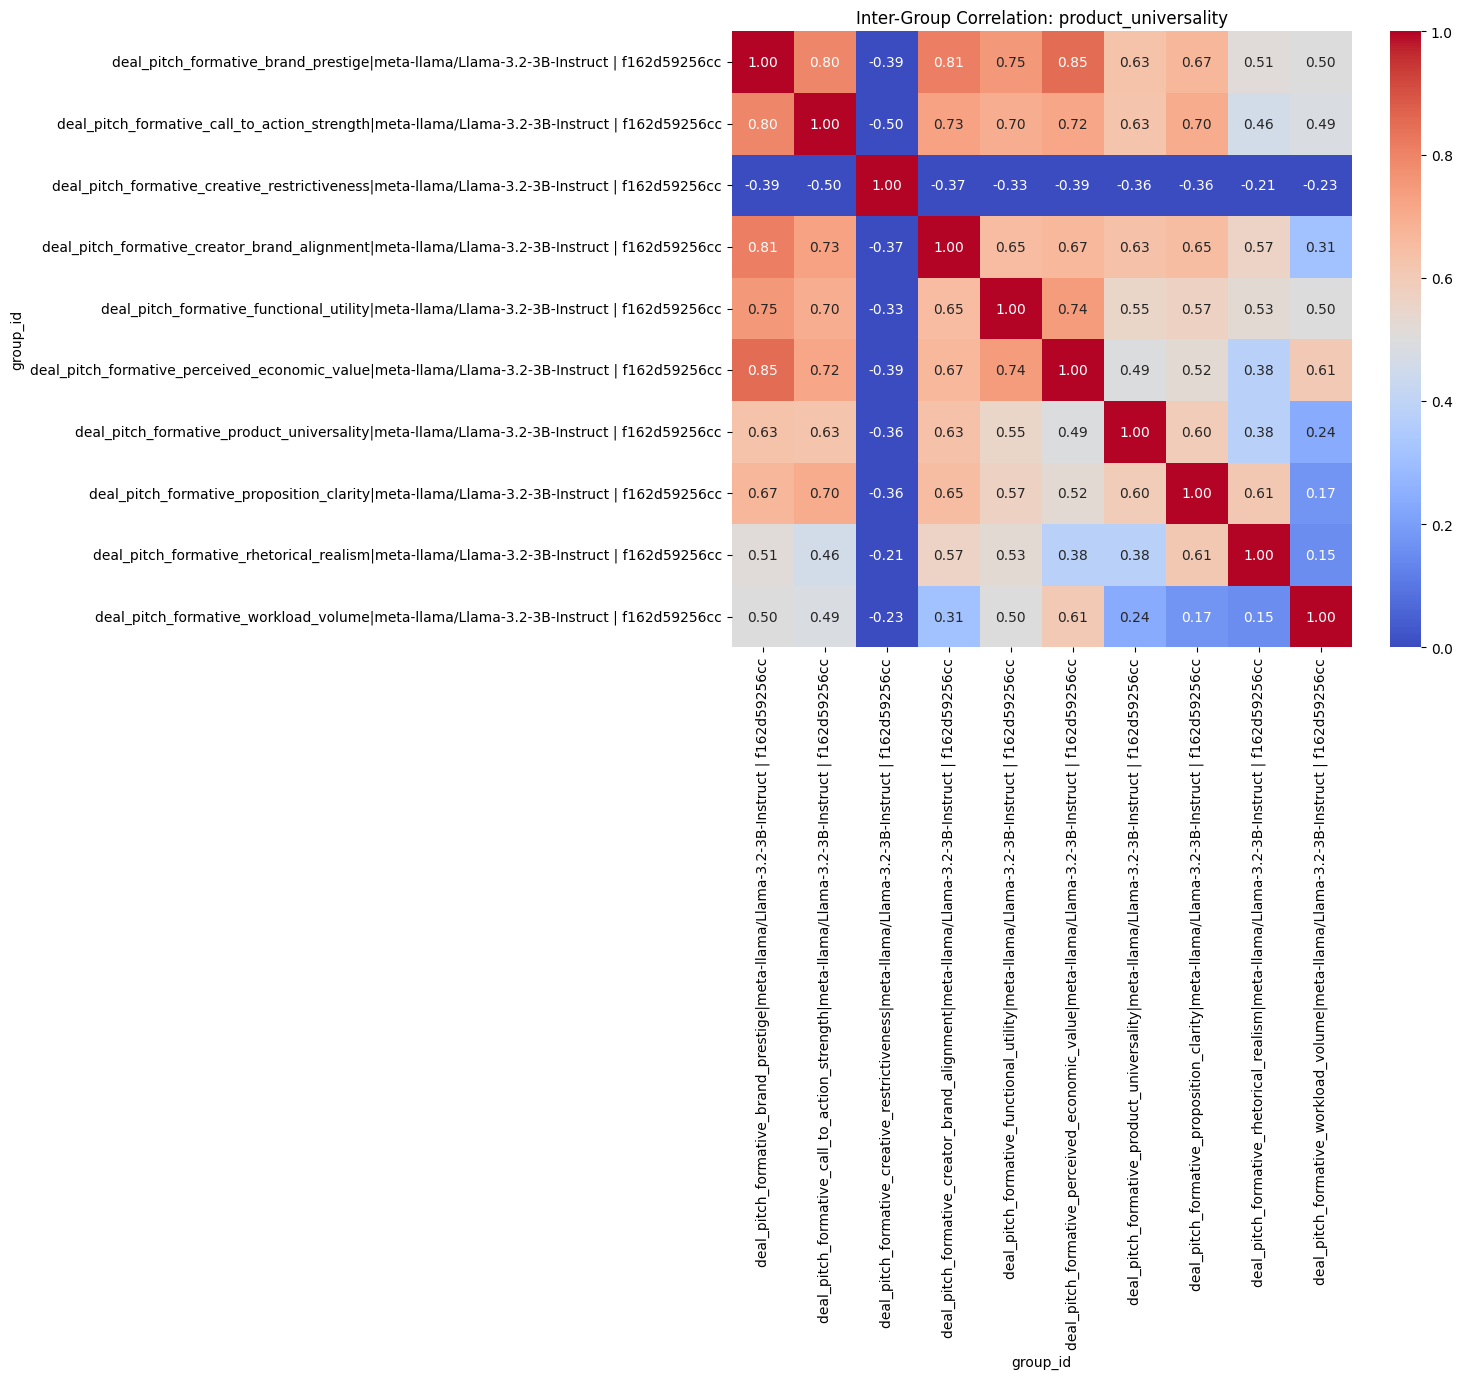

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def analyze_group_correlations(df, dimension="product_universality", score_col="mean_rating"):
    """
    Pivots long-form LLM data to compare experimental groups (Model + Prompt) 
    against each other for a specific dimension.
    """
    # 1. Create a unique identifier for each experimental group
    df = df.copy()
    df['group_id'] = df['dimension_name'] + "|" + \
        df['model_name'] + " | " + df['prompt_id']
    dim_df = df
    # 2. Filter for the dimension of interest
    # dim_df = df[df['dimension_name'] == dimension]

    # 3. Pivot to wide format
    # Index should be your unique deal identifier (e.g., 'deal_id' or 'id')
    # Use whatever column uniquely identifies the text being rated.
    pivot_df = dim_df.pivot_table(
        index='deal_id',
        columns='group_id',
        values=score_col
    )

    # 4. Calculate Correlation Matrix
    corr_matrix = pivot_df.corr()

    # corr_matrix.to_csv('corr_matrix_llama.csv')

    # 5. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
                fmt=".2f", vmin=0, vmax=1)
    plt.title(f"Inter-Group Correlation: {dimension}")
    plt.show()

    return corr_matrix


# Run the analysis
model_name = 'meta-llama/Llama-3.2-3B-Instruct'
# model_name = 'Qwen/Qwen3.5-4B'
prompt_id = 'f162d59256cc'
corr_results = analyze_group_correlations(final_df[(
    final_df['prompt_id'] == prompt_id) & (final_df['model_name'] == model_name)])
# corr_results

### Vifs

In [17]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- CONFIGURATION (Keep your existing setups here) ---
CONTENT_TYPE_COL = 'macro_category'
CATEGORICALS = ['market_scope', CONTENT_TYPE_COL, 'year_month']
CONTINUOUS = ['log_competitor_density_new', 'log_requirements_word_count']
BINARIES = ['strict_follower_requirement']
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']


def calculate_vif_for_pipeline(df):
    print("🚀 Initializing runner for VIF extraction...\n")

    # Initialize the runner to access its prepare_group_data method
    runner = create_regression_runner(
        target_col='apps_after_7_days',
        experimental_groups=EXPERIMENTAL_GROUPS,
        cluster_col='partner_id',
        model_type='negbin'
    )

    vif_records = []

    # Group the dataframe exactly as the runner does
    grouped = df.groupby(EXPERIMENTAL_GROUPS)

    for group_key, group_df in grouped:
        # We only care about checking VIF for the 10-dimension formative prompts
        # (Change 'f162d59256cc' if your formative prompt ID is different)
        if 'f162d59256cc' not in group_key:
            continue

        print(f"Pivoting data and calculating VIF for: {group_key}")

        # Use your runner's built-in pivoting method to get the X matrix
        prepared_data = runner.prepare_group_data(
            group_df=group_df,
            cat_predictors=CATEGORICALS,
            bin_predictors=BINARIES,
            num_predictors=CONTINUOUS,
            new_predictor='mean_rating'
        )

        if prepared_data is None or prepared_data['X'] is None:
            print(
                f"🚨 Skipping {group_key} - Could not build predictor matrix.")
            continue

        X = prepared_data['X']

        # statsmodels VIF requires a constant column to calculate correctly
        if 'const' not in X.columns:
            import statsmodels.api as sm
            X = sm.add_constant(X)

        # Calculate VIF for every column
        for i, col in enumerate(X.columns):
            # We only want to report the VIFs of your LLM dimensions, not the controls
            if 'formative' in col:
                try:
                    # variance_inflation_factor takes the matrix values and the index of the column
                    vif_val = variance_inflation_factor(X.values, i)
                    vif_records.append({
                        'Model': group_key[0],
                        'Prompt': group_key[1],
                        # Clean the variable name
                        'Variable': col.split('|')[0],
                        'VIF': vif_val
                    })
                except Exception as e:
                    print(f"Error calculating VIF for {col}: {e}")

    # Compile results
    vif_df = pd.DataFrame(vif_records)

    # Create a nice summary table: max and mean VIF per model
    summary_df = vif_df.groupby('Model')['VIF'].agg(
        ['mean', 'max', 'median']).round(2)
    print("\n=== VIF SUMMARY STATS ===")
    print(summary_df.to_markdown())

    return vif_df, summary_df, X


# ==========================================
# EXECUTION
# ==========================================
# Run it on your balanced dataframe
vif_details, vif_summary, X = calculate_vif_for_pipeline(final_df_balanced)

# Display the raw details sorted by highest VIF
display(vif_details.sort_values(by='VIF', ascending=False))

🚀 Initializing runner for VIF extraction...

Pivoting data and calculating VIF for: ('Qwen/Qwen3-4B-Instruct-2507', 'f162d59256cc')
Pivoting data and calculating VIF for: ('Qwen/Qwen3.5-4B', 'f162d59256cc')
Pivoting data and calculating VIF for: ('google/gemma-4-E2B-it', 'f162d59256cc')
Pivoting data and calculating VIF for: ('meta-llama/Llama-3.2-3B-Instruct', 'f162d59256cc')

=== VIF SUMMARY STATS ===
| Model                            |   mean |   max |   median |
|:---------------------------------|-------:|------:|---------:|
| Qwen/Qwen3-4B-Instruct-2507      |   1.64 |  2.34 |     1.54 |
| Qwen/Qwen3.5-4B                  |   1.62 |  2.31 |     1.52 |
| google/gemma-4-E2B-it            |   1.42 |  1.73 |     1.37 |
| meta-llama/Llama-3.2-3B-Instruct |   3.5  |  7.36 |     3.22 |


,Model,Prompt,Variable,VIF
30,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_brand_prestige,7.358499
31,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_perceived_economic_value,5.022959
37,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_call_to_action_strength,4.588236
32,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_creator_brand_alignment,3.896076
33,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_functional_utility,3.253655
39,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_proposition_clarity,3.177587
7,Qwen/Qwen3-4B-Instruct-2507,f162d59256cc,deal_pitch_formative_call_to_action_strength,2.341545
19,Qwen/Qwen3.5-4B,f162d59256cc,deal_pitch_formative_proposition_clarity,2.307689
34,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_product_universality,2.197403
2,Qwen/Qwen3-4B-Instruct-2507,f162d59256cc,deal_pitch_formative_creator_brand_alignment,2.138365


"Prior to fitting the Generalized Linear Models, multicollinearity diagnostics were conducted on the true formative (10-dimension) matrices using the Variance Inflation Factor (VIF). As indicated in Table Y, the Google Gemma 4 and Alibaba Qwen (3.0 and 3.5) architectures maintained strict dimensional orthogonality, with mean VIFs ≤1.64 and maximum VIFs ≤2.34, well below the conservative threshold of 5.0. Conversely, the Meta Llama 3.2 architecture exhibited severe structural multicollinearity (Mean VIF = 3.50, Max VIF = 7.36), specifically conflating Brand Prestige (VIF = 7.36) and Perceived Economic Value (VIF = 5.02). This indicates a collapse of Llama 3.2's internal latent space across high-inference text dimensions. Consequently, while Llama 3.2 is retained in the global model fit comparisons (AIC/Log-Likelihood) to demonstrate the universal trajectory of variance subsumption, its individual parameter estimates violate the assumption of non-collinearity and are strictly excluded from causal interpretation."

### Verbosity bias

In [18]:
final_df.groupby(EXPERIMENTAL_GROUPS)[
    ['input_length', 'mean_rating']].corr().reset_index()

,model_name,prompt_id,level_2,input_length,mean_rating
0,Qwen/Qwen3-4B-Instruct-2507,698a82f5d8a3,input_length,1.000000,0.157995
1,Qwen/Qwen3-4B-Instruct-2507,698a82f5d8a3,mean_rating,0.157995,1.000000
2,Qwen/Qwen3-4B-Instruct-2507,6faa8a8b031c,input_length,1.000000,0.342047
3,Qwen/Qwen3-4B-Instruct-2507,6faa8a8b031c,mean_rating,0.342047,1.000000
4,Qwen/Qwen3-4B-Instruct-2507,f162d59256cc,input_length,1.000000,0.123737
5,Qwen/Qwen3-4B-Instruct-2507,f162d59256cc,mean_rating,0.123737,1.000000
6,Qwen/Qwen3.5-4B,698a82f5d8a3,input_length,1.000000,0.050041
7,Qwen/Qwen3.5-4B,698a82f5d8a3,mean_rating,0.050041,1.000000
8,Qwen/Qwen3.5-4B,6faa8a8b031c,input_length,1.000000,-0.069804
9,Qwen/Qwen3.5-4B,6faa8a8b031c,mean_rating,-0.069804,1.000000


In [19]:
# final_df.groupby(EXPERIMENTAL_GROUPS + ['dimension_name'])[['input_length', 'mean_rating']].corr().reset_index().to_csv('verbosity_bias.csv')
final_df.groupby(EXPERIMENTAL_GROUPS + ['dimension_name']
                 )[['input_length', 'mean_rating']].corr().reset_index()

,model_name,prompt_id,dimension_name,level_3,input_length,mean_rating
0,Qwen/Qwen3-4B-Instruct-2507,698a82f5d8a3,deal_pitch_holistic_burden_acceptability,input_length,1.000000,0.003474
1,Qwen/Qwen3-4B-Instruct-2507,698a82f5d8a3,deal_pitch_holistic_burden_acceptability,mean_rating,0.003474,1.000000
2,Qwen/Qwen3-4B-Instruct-2507,698a82f5d8a3,deal_pitch_holistic_pitch_professionalism,input_length,1.000000,0.266004
3,Qwen/Qwen3-4B-Instruct-2507,698a82f5d8a3,deal_pitch_holistic_pitch_professionalism,mean_rating,0.266004,1.000000
4,Qwen/Qwen3-4B-Instruct-2507,698a82f5d8a3,deal_pitch_holistic_reward_attractiveness,input_length,1.000000,0.253543
...,...,...,...,...,...,...
107,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_proposition_clarity,mean_rating,0.241639,1.000000
108,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_rhetorical_realism,input_length,1.000000,0.284014
109,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_rhetorical_realism,mean_rating,0.284014,1.000000
110,meta-llama/Llama-3.2-3B-Instruct,f162d59256cc,deal_pitch_formative_workload_volume,input_length,1.000000,0.332296


## Regressions

### Fit models

In [20]:
print(og_df.groupby('deal_type')['apps_after_7_days'].describe())

            count       mean        std  min  25%  50%   75%    max
deal_type                                                          
online     2569.0  16.130790  22.660745  0.0  3.0  8.0  21.0  265.0
physical    557.0  14.567325  18.019909  0.0  3.0  9.0  19.0  133.0


#### Basic

In [21]:
import numpy as np

print("--- 🚀 REGROUPING PLATFORMS FOR STATISTICAL STABILITY ---")

# We update the conditions to fold YouTube, Facebook, and Omnichannel into one bucket
conditions = [
    (og_df_balanced['req_instagram'] == 1) & (
        og_df_balanced['platform_count'] == 1),
    (og_df_balanced['req_tiktok'] == 1) & (
        og_df_balanced['platform_count'] == 1),
    (og_df_balanced['req_instagram'] == 1) & (
        og_df_balanced['req_tiktok'] == 1) & (og_df_balanced['platform_count'] == 2),
    # Keep Unspecified separate, as it means "blank"
    (og_df_balanced['platform_count'] == 0)
]

choices = [
    'Instagram_Only',
    'TikTok_Only',
    'IG_and_TikTok',
    'Unspecified'
]

# Anything that doesn't fit the simple IG/TikTok molds (e.g., YouTube, 3+ platforms, FB)
# gets grouped into a catch-all high-complexity bucket.
og_df_balanced['platform_strategy'] = np.select(
    conditions,
    choices,
    default='High_Friction_Deliverable'
)

print("\nUpdated Distribution in Base Data:")
print(og_df_balanced['platform_strategy'].value_counts())

--- 🚀 REGROUPING PLATFORMS FOR STATISTICAL STABILITY ---

Updated Distribution in Base Data:
platform_strategy
IG_and_TikTok                1051
Unspecified                   838
TikTok_Only                   473
Instagram_Only                437
High_Friction_Deliverable     271
Name: count, dtype: int64


In [22]:
final_df_balanced.prompt_id.unique()

array(['698a82f5d8a3', '6faa8a8b031c', 'f162d59256cc'], dtype=object)

In [23]:
CONTENT_TYPE_COL = 'macro_category'

CATEGORICALS = ['market_scope', CONTENT_TYPE_COL,
                'year_month', 'platform_strategy']
CONTINUOUS = ['log_competitor_density_new', 'log_requirements_word_count']
CONTINUOUS = ['log_competitor_density_new', 'log_requirements_word_count',
              'log_title_word_count', 'log_text_word_count']

BINARIES = ['strict_follower_requirement']
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']

runner = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

runner.run_baseline_model(
    df=og_df_balanced,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline"
)


# predictor_name = 'mean_rating'
predictor_name = 'z_mean_rating'

runner.run_regression(df=final_df_balanced,
                      cat_vars=CATEGORICALS,
                      bin_vars=BINARIES,
                      num_vars=CONTINUOUS,
                      predictor_name=predictor_name)

interactive_regression_results_selector(runner.results)

✓ Baseline model fitted: 3070 observations, AIC=22045.26


Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', "('Qwen/Qwen3-4B-Ins…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 3070
Model:               NegativeBinomial   Df Residuals:                     3038
Method:                           MLE   Df Model:                           31
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                 0.05107
Time:                        14:49:06   Log-Likelihood:                -10990.
converged:                       True   LL-Null:                       -11581.
Covariance Type:              cluster   LLR p-value:                6.437e-229
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    2.4710      0.280      8.815      0.000       1.921       3.021
strict_follower_requirement             -0.1599      0.060     -2.665      0.008      -0.278      -0.042
log_competitor_density_new              -0.1927      0.042     -4.614      0.000      -0.275      -0.111
log_requirements_word_count             -0.0327      0.030     -1.083      0.279      -0.092       0.027
log_title_word_count                     0.0705      0.072      0.982      0.326      -0.070       0.211
log_text_word_count                     -0.0089      0.030     -0.302      0.762      -0.067       0.049
market_scope_Tier2_NLD_only             -0.3732      0.067     -5.570      0.000      -0.505      -0.242
market_scope_Tier3_BEL_Only             -1.2570      0.179     -7.035      0.000      -1.608      -0.906
market_scope_Tier4_Germany              -1.6653      0.079    -20.975      0.000      -1.821      -1.509
macro_category_Beauty                    0.6344      0.195      3.251      0.001       0.252       1.017
macro_category_Digital Entertainment    -0.1569      0.206     -0.762      0.446      -0.561       0.247
macro_category_Dining & Hospitality      0.2368      0.198      1.194      0.233      -0.152       0.626
macro_category_Family & Parenting       -0.0844      0.222     -0.380      0.704      -0.520       0.351
macro_category_Fashion                   0.5335      0.209      2.555      0.011       0.124       0.943
macro_category_Home Cooking & CPG        0.3219      0.191      1.681      0.093      -0.054       0.698
macro_category_In-Person Experiences    -0.3836      0.239     -1.608      0.108      -0.852       0.084
macro_category_Lifestyle & Home          0.5449      0.203      2.686      0.007       0.147       0.943
macro_category_Tech & Niche             -0.2766      0.267     -1.036      0.300      -0.800       0.247
year_month_2025-06                       0.2396      0.111      2.152      0.032       0.021       0.458
year_month_2025-07                       0.4128      0.109      3.783      0.000       0.199       0.627
year_month_2025-08                       0.0995      0.120      0.827      0.409      -0.137       0.336
year_month_2025-09                       0.1759      0.112      1.564      0.118      -0.045       0.397
year_month_2025-10                       0.5944      0.117      5.084      0.000       0.365       0.824
year_month_2025-11                       0.4717      0.121      3.893      0.000       0.234       0.709
year_month_2025-12                       0.5017      0.155      3.242      0.001       0.198       0.805
year_month_2026-01                       0.3204      0.127      2.527      0.012       0.072       0.569
year_month_2026-02                       0.4173      0.151      2.757      0.006       0.120       0.714
year_month_2026-03                       0.8701      0.204      4.270      0.000       0.47

"While the inherent complexity of semantic structures makes it impossible to eliminate all measurement bias, the LLM provides a deterministic, internally consistent metric that is free from the fatigue and idiosyncratic noise of human coders. The success of the model in identifying other primary economic drivers (Product Universality, Economic Value) provides a high-degree of 'internal instrument validity,' suggesting that the null findings for Workload Volume are more likely a reflection of market-level behavior than a systematic failure of the semantic encoding process."


4. The "Noisy Ground Truth" Problem

Finally, consider that the LLM might be a better judge than the human creators are. Human creators are "noisy." They apply to things while they are tired, distracted, or in a rush. The LLM is a "distilled" version of human preference.
If the LLM identifies a workload as "7" and creators still apply, it might not be that the LLM is biased; it’s that humans are inconsistent. In econometrics, we call this Unobserved Heterogeneity. The LLM is measuring the "Idealized Workload," but the "Real World Workload" is filtered through a thousand creator-specific lenses.

In [24]:
final_df_balanced.deal_id

0         01968a82-9063-00c8-a178-56bbf92db1d9
1         01968a82-9063-00c8-a178-56bbf92db1d9
2         01968a82-9063-00c8-a178-56bbf92db1d9
3         01968a82-9063-00c8-a178-56bbf92db1d9
4         01968a82-9063-00c8-a178-56bbf92db1d9
                          ...                 
171915    019cd706-b9ac-00c8-e09b-93042ef88364
171916    019cd706-b9ac-00c8-e09b-93042ef88364
171917    019cd706-b9ac-00c8-e09b-93042ef88364
171918    019cd706-b9ac-00c8-e09b-93042ef88364
171919    019cd706-b9ac-00c8-e09b-93042ef88364
Name: deal_id, Length: 171920, dtype: object

#### Mega model

In [25]:
# DEFINE VARIABLES
from IPython.display import display, clear_output
import ipywidgets as widgets
CONTENT_TYPE_COL = ['consolidated_categories', 'macro_category'][1]

CATEGORICALS = ['market_scope', CONTENT_TYPE_COL, 'year_week']
CATEGORICALS = ['market_scope', CONTENT_TYPE_COL, 'year_month', 'deal_type']
CATEGORICALS = ['market_scope', CONTENT_TYPE_COL, 'year_month']


# CATEGORICALS = ['market_scope', 'consolidated_categories', 'deal_type']


CONTINUOUS = ['competitor_density', 'log_title_word_count',
              'log_text_word_count', 'log_requirements_word_count']
CONTINUOUS = ['competitor_density']
CONTINUOUS = ['log_competitor_density_new', 'log_requirements_word_count']
# CONTINUOUS = ['log_competitor_density', 'log_requirements_word_count']

# CONTINUOUS = ['competitor_density', 'log_requirements_word_count']
BINARIES = ['strict_follower_requirement']


# Experimental groups (required by your BaseRegressionRunner)
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']


# RUN MODEL

# 1. Create a copy of your balanced dataframe
mega_df = final_df_balanced.copy()


# prompts_to_include = ['16071a84cca9',
#                       '5f7ea2deacb8', '26fac938d6ea', 'd39649b54a27']
# prompts_to_include = ['722bbd35b498', '1dd96c436d00', 'c346be6c6bbc']
# prompts_to_include = ['b30bc4372567', 'c346be6c6bbc']
prompts_to_include = final_df.prompt_id.unique().tolist()


mega_df = mega_df[mega_df['prompt_id'].isin(prompts_to_include)]


# 2. Create a globally unique dimension name by concatenating the metadata
mega_df['dimension_name'] = (
    mega_df['model_name'] + "_" +
    mega_df['prompt_id'] + "_" +
    mega_df['dimension_name']
)


# 3. Create a single dummy group so the runner doesn't split the data
mega_df['mega_group'] = 'all_predictors'


# 1. Get all unique dimensions from your mega dataframe
all_variables = sorted(mega_df['dimension_name'].unique().tolist())

# 2. Create the interactive multi-select widget
variable_selector = widgets.SelectMultiple(
    options=all_variables,
    value=all_variables,  # Default selects all of them (Kitchen Sink)
    rows=15,
    description='Variables:',
    layout=widgets.Layout(width='80%')
)

run_button = widgets.Button(
    description='Run Custom Model',
    button_style='success',
    icon='play'
)

output_area = widgets.Output()


def run_custom_regression(b):
    with output_area:
        clear_output(wait=True)
        selected_vars = list(variable_selector.value)

        if not selected_vars:
            print("⚠️ Please select at least one variable.")
            return

        print(
            f"🚀 Running OLS with {len(selected_vars)} selected dimensions...\n")

        # CORE MECHANIC: Filter the long dataframe to ONLY include selected variables
        # When the runner pivots this, the excluded variables simply won't exist!
        filtered_df = mega_df[mega_df['dimension_name'].isin(
            selected_vars)].copy()

        # Re-initialize the runner
        custom_runner = create_regression_runner(
            target_col='apps_after_7_days',
            experimental_groups=['mega_group'],
            cluster_col='partner_id',
            model_type='negbin'
        )

        # Fit the model
        custom_runner.run_regression(
            df=filtered_df,
            cat_vars=CATEGORICALS,
            bin_vars=BINARIES,
            num_vars=CONTINUOUS,
            predictor_name='z_mode_rating'
        )

        # Display the statsmodels summary table
        # The key is ('mega_group',) because of how groupby handles single-item lists

        # Safely attempt to fetch the result
        result = custom_runner.results.get("('all_predictors',)")

        if result is not None:
            print(result.summary())
        else:
            print("🚨 MODEL FAILED TO CONVERGE.")
            print("Check for Perfect Multicollinearity. One of your binary variables (like friction) is likely all 0s, or a category has 0 observations.")
        # result = custom_runner.results["('all_predictors',)"]
        # if result:
        #     print(result.summary())
        # else:
        #     print("🚨 Model failed to converge. Check your variable mix.")


# 3. Render the UI
run_button.on_click(run_custom_regression)
display(variable_selector, run_button, output_area)

SelectMultiple(description='Variables:', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, …

Button(button_style='success', description='Run Custom Model', icon='play', style=ButtonStyle())

Output()

"When semi-formative, high-inference constructs (e.g., 'Reward Attractiveness') are modeled alongside granular, low-to-medium inference dimensions (e.g., 'Economic Value', 'Universality'), the holistic constructs lose all predictive validity. Their variance is entirely subsumed by the manifest dimensions. This proves that high-inference LLM measurement introduces severe, non-random measurement error (attenuation bias) that obscures true behavioral causality. Therefore, to achieve valid, generalizable predictive models using LLMs, researchers must abandon holistic 'vibe' prompts. Constructs must be rigorously deconstructed into low-inference, manifest text features, allowing classical econometric models to handle the aggregation, rather than relying on the LLM's flawed internal latent space."

#### Baseline model

In [26]:
# Baseline model

negbin_runner = create_regression_runner(
    target_col='apps_after_7_days',
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

nb_results = negbin_runner.run_baseline_model(
    df=og_df_balanced,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="Baseline_NegBin"
)

print(nb_results['Baseline_NegBin'].summary())

✓ Baseline model fitted: 3070 observations, AIC=22059.00
                     NegativeBinomial Regression Results                      
Dep. Variable:      apps_after_7_days   No. Observations:                 3070
Model:               NegativeBinomial   Df Residuals:                     3044
Method:                           MLE   Df Model:                           25
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                 0.04996
Time:                        14:49:07   Log-Likelihood:                -11002.
converged:                       True   LL-Null:                       -11581.
Covariance Type:              cluster   LLR p-value:                2.281e-228
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    2.8605      0.227     12.579      0.000       2.414       3.

### Model diagnostics

#### Compare coefficient magnitude

In [27]:
import pandas as pd
import ast

# --- CONFIGURATION ---
CONTENT_TYPE_COL = 'macro_category'
CATEGORICALS = ['market_scope', CONTENT_TYPE_COL, 'year_month']
CONTINUOUS = ['log_competitor_density_new', 'log_requirements_word_count']
BINARIES = ['strict_follower_requirement']
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']


def generate_coefficient_matrix(df, predictor_col):
    print(f"🚀 Running pipeline for aggregation method: {predictor_col}...\n")

    # 1. Initialize and run the model natively
    runner = create_regression_runner(
        target_col='apps_after_7_days',
        experimental_groups=EXPERIMENTAL_GROUPS,
        cluster_col='partner_id',
        model_type='negbin'
    )

    runner.run_regression(
        df=df,
        cat_vars=CATEGORICALS,
        bin_vars=BINARIES,
        num_vars=CONTINUOUS,
        predictor_name=predictor_col
    )

    # 2. Extract and clean the coefficients
    records = []
    for group_key, result in runner.results.items():
        if result is None:
            continue

        # Safely parse the group_key back into a tuple if it's a string
        if isinstance(group_key, str) and group_key.startswith("("):
            try:
                parsed_key = ast.literal_eval(group_key)
                model_name = parsed_key[0]
                prompt_id = parsed_key[1]
            except Exception as e:
                print(f"🚨 Failed to parse key {group_key}: {e}")
                continue
        elif isinstance(group_key, tuple):
            model_name = group_key[0]
            prompt_id = group_key[1]
        else:
            continue

        for var_name, coef in result.params.items():
            # We only want the LLM-extracted variables
            if 'formative' in var_name or 'holistic' in var_name:

                # Strip the model and prompt_id prefixes to ensure perfect row alignment
                clean_var_name = var_name.split(prompt_id + '_')[-1]

                records.append({
                    'Variable': clean_var_name,
                    'Model': model_name,
                    'Coefficient': round(coef, 4)
                })

    # 3. Pivot into a clean comparative matrix
    coef_df = pd.DataFrame(records)

    if coef_df.empty:
        print("🚨 No coefficients extracted. Check variable names or prompt IDs.")
        return None

    # Pivot matrix
    pivot_matrix = coef_df.pivot(
        index='Variable', columns='Model', values='Coefficient')

    # Sort the index to group holistic, macro, and formative variables logically
    pivot_matrix = pivot_matrix.sort_index()

    return pivot_matrix


# ==========================================
# EXECUTION
# ==========================================
# Note: Ensure final_df_balanced contains both mean and mode target columns
prompts_to_include = final_df_balanced.prompt_id.unique().tolist()
df_to_run = final_df_balanced[final_df_balanced['prompt_id'].isin(
    prompts_to_include)].copy()

# Note: Adjust 'mean_rating' and 'mode_rating' if your column names differ
matrix_mean = generate_coefficient_matrix(
    df_to_run, predictor_col='mean_rating')
matrix_mode = generate_coefficient_matrix(
    df_to_run, predictor_col='mode_rating')

print("\n=== COEFFICIENT MAGNITUDES (USING MEAN) ===")
if matrix_mean is not None:
    display(matrix_mean)

print("\n=== COEFFICIENT MAGNITUDES (USING MODE) ===")
if matrix_mode is not None:
    display(matrix_mode)

🚀 Running pipeline for aggregation method: mean_rating...

🚀 Running pipeline for aggregation method: mode_rating...


=== COEFFICIENT MAGNITUDES (USING MEAN) ===


Model,Qwen/Qwen3-4B-Instruct-2507,Qwen/Qwen3.5-4B,google/gemma-4-E2B-it,meta-llama/Llama-3.2-3B-Instruct
Variable,,,,
deal_pitch_formative_brand_prestige,0.0722,-0.0600,0.0296,-0.0925
deal_pitch_formative_call_to_action_strength,-0.0478,-0.0304,0.0036,-0.2872
deal_pitch_formative_creative_restrictiveness,-0.1032,-0.0684,-0.0180,-0.1412
deal_pitch_formative_creator_brand_alignment,-0.0250,0.0576,0.0017,0.1504
deal_pitch_formative_functional_utility,-0.0839,-0.1587,-0.1320,-0.3597
deal_pitch_formative_perceived_economic_value,0.1600,0.3703,0.3839,0.2427
deal_pitch_formative_product_universality,0.2032,0.5551,0.2794,0.3368
deal_pitch_formative_proposition_clarity,-0.0010,-0.0844,0.0656,0.2420
deal_pitch_formative_rhetorical_realism,-0.0747,0.0932,-0.0172,-0.1364



=== COEFFICIENT MAGNITUDES (USING MODE) ===


Model,Qwen/Qwen3-4B-Instruct-2507,Qwen/Qwen3.5-4B,google/gemma-4-E2B-it,meta-llama/Llama-3.2-3B-Instruct
Variable,,,,
deal_pitch_formative_brand_prestige,0.0688,-0.0597,0.0302,-0.0788
deal_pitch_formative_call_to_action_strength,-0.0378,-0.0122,0.0304,-0.0473
deal_pitch_formative_creative_restrictiveness,-0.0478,-0.0257,-0.0204,0.0567
deal_pitch_formative_creator_brand_alignment,-0.0024,0.0399,0.0171,0.0485
deal_pitch_formative_functional_utility,-0.0599,-0.0464,-0.1000,-0.0282
deal_pitch_formative_perceived_economic_value,0.1370,0.1765,0.2445,0.0449
deal_pitch_formative_product_universality,0.1850,0.4348,0.2265,0.0864
deal_pitch_formative_proposition_clarity,-0.0142,-0.0300,0.0279,0.1175
deal_pitch_formative_rhetorical_realism,-0.0686,0.0696,-0.0146,-0.0635


In [28]:
df_coef_diff = abs(matrix_mean) - abs(matrix_mode)
# df_coef_diff.to_csv('diff_mean_mode_coefs.csv')

df_coef_diff

Model,Qwen/Qwen3-4B-Instruct-2507,Qwen/Qwen3.5-4B,google/gemma-4-E2B-it,meta-llama/Llama-3.2-3B-Instruct
Variable,,,,
deal_pitch_formative_brand_prestige,0.0034,0.0003,-0.0006,0.0137
deal_pitch_formative_call_to_action_strength,0.0100,0.0182,-0.0268,0.2399
deal_pitch_formative_creative_restrictiveness,0.0554,0.0427,-0.0024,0.0845
deal_pitch_formative_creator_brand_alignment,0.0226,0.0177,-0.0154,0.1019
deal_pitch_formative_functional_utility,0.0240,0.1123,0.0320,0.3315
deal_pitch_formative_perceived_economic_value,0.0230,0.1938,0.1394,0.1978
deal_pitch_formative_product_universality,0.0182,0.1203,0.0529,0.2504
deal_pitch_formative_proposition_clarity,-0.0132,0.0544,0.0377,0.1245
deal_pitch_formative_rhetorical_realism,0.0061,0.0236,0.0026,0.0729


#### Export all LLM model outputs

In [29]:
import pandas as pd
import datetime
from statsmodels.stats.multitest import multipletests

# --- CONFIGURATION ---
CONTENT_TYPE_COL = 'macro_category'
CATEGORICALS = ['market_scope', CONTENT_TYPE_COL, 'year_month']
CONTINUOUS = ['log_competitor_density_new', 'log_requirements_word_count']
BINARIES = ['strict_follower_requirement']

# Leave the experimental groups as they natively are
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']


def run_and_export_all_groups(df):
    print("🚀 Initializing runner and fitting models across all experimental groups...\n")

    # 1. Initialize the runner natively
    runner = create_regression_runner(
        target_col='apps_after_7_days',
        experimental_groups=EXPERIMENTAL_GROUPS,
        cluster_col='partner_id',
        model_type='negbin'
    )

    # 2. Fit the model
    runner.run_regression(
        df=df,
        cat_vars=CATEGORICALS,
        bin_vars=BINARIES,
        num_vars=CONTINUOUS,
        predictor_name='mean_rating'
    )

    # 3. Iterate over the results dictionary and export
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    exported_files = []

    # Store all dataframes in a dictionary so they can be accessed in the notebook
    all_results_dfs = {}

    for group_key, result in runner.results.items():
        if result is None:
            print(f"🚨 FAILED TO CONVERGE: Group {group_key}")
            continue

        # Clean the group key for the filename
        if isinstance(group_key, tuple):
            clean_name = "_".join([str(k).replace("/", "-")
                                  for k in group_key])
        else:
            clean_name = str(group_key).replace("/", "-")

        filename = f"Regression_{clean_name}_{timestamp}.csv"

        # Extract main coefficient data
        results_df = pd.DataFrame({
            'Variable': result.params.index,
            'Coefficient': result.params.values,
            'Std_Error': result.bse.values,
            'z_stat': result.tvalues.values,
            'p_value': result.pvalues.values,
            'CI_Lower': result.conf_int()[0].values,
            'CI_Upper': result.conf_int()[1].values
        })

        # --- AUTOMATED FDR CORRECTION ---
        # Isolate the 'family of hypotheses' (only LLM dimensions, excluding controls)
        llm_var_mask = results_df['Variable'].str.contains(
            'formative|holistic')

        # Initialize the new columns
        results_df['p_value_FDR_corrected'] = None
        results_df['Significant_after_FDR'] = None

        if llm_var_mask.sum() > 0:
            reject, pvals_corrected, _, _ = multipletests(
                pvals=results_df.loc[llm_var_mask, 'p_value'],
                alpha=0.05,
                method='fdr_bh'
            )
            results_df.loc[llm_var_mask,
                           'p_value_FDR_corrected'] = pvals_corrected
            results_df.loc[llm_var_mask, 'Significant_after_FDR'] = reject

        # --- MODEL FIT STATS ---
        pseudo_r2 = getattr(result, 'prsquared', 'N/A')

        fit_stats = pd.DataFrame({
            'Variable': ['---', 'Log-Likelihood', 'AIC', 'Pseudo_R_Squared', 'Observations', 'DF_Model'],
            'Coefficient': [None, result.llf, result.aic, pseudo_r2, result.nobs, result.df_model],
            'Std_Error': [None]*6,
            'z_stat': [None]*6,
            'p_value': [None]*6,
            'CI_Lower': [None]*6,
            'CI_Upper': [None]*6,
            'p_value_FDR_corrected': [None]*6,
            'Significant_after_FDR': [None]*6
        })

        # Combine and export
        export_df = pd.concat([results_df, fit_stats], ignore_index=True)
        export_df.to_csv(filename, index=False)

        exported_files.append(filename)
        all_results_dfs[clean_name] = export_df

        print(f"✅ Exported: {filename}")

    print(f"\n🎉 Finished. Exported {len(exported_files)} files.")

    return all_results_dfs


# ==========================================
# EXECUTION
# ==========================================
# Filter to the prompts you actually want to run, then execute:
prompts_to_include = final_df_balanced.prompt_id.unique().tolist()
df_to_run = final_df_balanced[final_df_balanced['prompt_id'].isin(
    prompts_to_include)].copy()

all_results_dict = run_and_export_all_groups(df_to_run)

# # Display the first dataframe in the notebook to verify output
# if all_results_dict:
#     first_model_key = list(all_results_dict.keys())[0]
#     display(all_results_dict[first_model_key])

🚀 Initializing runner and fitting models across all experimental groups...



C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\2625779337.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  export_df = pd.concat([results_df, fit_stats], ignore_index=True)
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\2625779337.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  export_df = pd.concat([results_df, fit_stats], ignore_index=True)
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\2625779337.py:102: FutureWarning: The behavior of DataFrame conc

✅ Exported: Regression_('Qwen-Qwen3-4B-Instruct-2507', '698a82f5d8a3')_20260421_1449.csv
✅ Exported: Regression_('Qwen-Qwen3-4B-Instruct-2507', '6faa8a8b031c')_20260421_1449.csv
✅ Exported: Regression_('Qwen-Qwen3-4B-Instruct-2507', 'f162d59256cc')_20260421_1449.csv
✅ Exported: Regression_('Qwen-Qwen3.5-4B', '698a82f5d8a3')_20260421_1449.csv
✅ Exported: Regression_('Qwen-Qwen3.5-4B', '6faa8a8b031c')_20260421_1449.csv


C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\2625779337.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  export_df = pd.concat([results_df, fit_stats], ignore_index=True)
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\2625779337.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  export_df = pd.concat([results_df, fit_stats], ignore_index=True)
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\2625779337.py:102: FutureWarning: The behavior of DataFrame conc

✅ Exported: Regression_('Qwen-Qwen3.5-4B', 'f162d59256cc')_20260421_1449.csv
✅ Exported: Regression_('google-gemma-4-E2B-it', '698a82f5d8a3')_20260421_1449.csv
✅ Exported: Regression_('google-gemma-4-E2B-it', '6faa8a8b031c')_20260421_1449.csv
✅ Exported: Regression_('google-gemma-4-E2B-it', 'f162d59256cc')_20260421_1449.csv
✅ Exported: Regression_('meta-llama-Llama-3.2-3B-Instruct', '698a82f5d8a3')_20260421_1449.csv
✅ Exported: Regression_('meta-llama-Llama-3.2-3B-Instruct', '6faa8a8b031c')_20260421_1449.csv
✅ Exported: Regression_('meta-llama-Llama-3.2-3B-Instruct', 'f162d59256cc')_20260421_1449.csv

🎉 Finished. Exported 12 files.


C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\2625779337.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  export_df = pd.concat([results_df, fit_stats], ignore_index=True)
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\2625779337.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  export_df = pd.concat([results_df, fit_stats], ignore_index=True)


In [30]:
def interactive_dataframe_selector(data_dict, description="Select option:"):
    # label -> value pairs; value is the tuple key
    options = [k for k in data_dict.keys()]
    dropdown = widgets.Dropdown(
        options=options,
        description=description,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    def update_table(change):
        clear_output(wait=True)
        display(dropdown)
        display(data_dict[change.new])

    dropdown.observe(update_table, names='value')
    display(dropdown)
    display(data_dict[dropdown.value])


interactive_dataframe_selector(all_results_dict)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen-Qwen3-4B-Instruct-2507',…

,Variable,Coefficient,Std_Error,z_stat,p_value,CI_Lower,CI_Upper,p_value_FDR_corrected,Significant_after_FDR
0,const,2.577830,0.341887,7.540002,9.459400e-14,1.907042,3.248617,None,None
1,deal_pitch_holistic_reward_attractiveness,0.184403,0.037209,4.955926,8.270146e-07,0.111399,0.257407,0.000002,True
2,deal_pitch_holistic_burden_acceptability,0.037795,0.024982,1.512884,1.305820e-01,-0.011220,0.086809,0.195873,False
3,deal_pitch_holistic_pitch_professionalism,-0.030752,0.030846,-0.996953,3.189955e-01,-0.091272,0.029768,0.318996,False
4,strict_follower_requirement,-0.185959,0.058475,-3.180141,1.511086e-03,-0.300688,-0.071230,None,None
5,log_competitor_density_new,-0.190222,0.042586,-4.466776,8.717750e-06,-0.273776,-0.106668,None,None
6,log_requirements_word_count,-0.079965,0.025856,-3.092701,2.030889e-03,-0.130695,-0.029235,None,None
7,market_scope_Tier2_NLD_only,-0.359438,0.066960,-5.367940,9.615691e-08,-0.490814,-0.228061,None,None
8,market_scope_Tier3_BEL_Only,-1.225524,0.179081,-6.843389,1.250819e-11,-1.576885,-0.874164,None,None
9,market_scope_Tier4_Germany,-1.663466,0.080059,-20.777979,9.417996e-82,-1.820543,-1.506388,None,None


## Experiments

#### Interaction effects

In [31]:
import statsmodels.api as sm

print("\n--- 🚀 SATURDAY EDA: INTERACTION EFFECTS ---")

# 1. Isolate the optimal Qwen 3.5 Formative prompt
model_name = 'Qwen/Qwen3.5-4B'
prompt_id = 'f162d59256cc'  # Change if your formative prompt ID is different
qwen_df = final_df_balanced[(final_df_balanced['model_name'] == model_name) &
                            (final_df_balanced['prompt_id'] == prompt_id)].copy()

if not qwen_df.empty:
    # 2. Get the base 'mean_rating' wide matrix (This contains your Main Effects)
    prepared_mean = runner.prepare_group_data(
        group_df=qwen_df,
        cat_predictors=CATEGORICALS,
        bin_predictors=BINARIES,
        num_predictors=CONTINUOUS,
        new_predictor='mean_rating'
    )
    X_base = prepared_mean['X'].copy()
    y = prepared_mean['y']

    # 3. Get the 'normalized_entropy' wide matrix
    prepared_entropy = runner.prepare_group_data(
        group_df=qwen_df,
        cat_predictors=CATEGORICALS,
        bin_predictors=BINARIES,
        num_predictors=CONTINUOUS,
        new_predictor='normalized_entropy'
    )
    X_entropy = prepared_entropy['X'].copy()

    # 4. Create the Interaction Matrix
    X_interactions = X_base.copy()  # Start with all main effects (Ratings + Controls)

    # --- IDEA 1: THE FATIGUE PENALTY (Rating x Word Count) ---
    # Does length make strictness or CTAs worse?
    X_interactions['int_cta_x_length'] = (
        X_base['deal_pitch_formative_call_to_action_strength'] *
        X_base['log_requirements_word_count']
    )
    X_interactions['int_restrict_x_length'] = (
        X_base['deal_pitch_formative_creative_restrictiveness'] *
        X_base['log_requirements_word_count']
    )

    # --- IDEA 2: THE UNCERTAINTY DISCOUNT (Rating x Entropy) ---
    # Does LLM confusion (entropy) discount the perceived value of the deal?
    # Note: Ensure we add the main effect for Entropy first so we don't violate the rule!
    X_interactions['entropy_perceived_economic_value'] = X_entropy['deal_pitch_formative_perceived_economic_value']

    X_interactions['int_econ_value_x_entropy'] = (
        X_base['deal_pitch_formative_perceived_economic_value'] *
        X_interactions['entropy_perceived_economic_value']
    )

    # Make sure we have a constant for statsmodels
    if 'const' not in X_interactions.columns:
        X_interactions = sm.add_constant(X_interactions)

    # 5. Fit the Model!
    print("Fitting Interaction Model for Qwen 3.5...")
    try:
        interaction_model = sm.NegativeBinomial(
            y, X_interactions).fit(disp=False, maxiter=1000)

        print("\n==============================================================================")
        print(
            "                      QWEN 3.5 INTERACTION EFFECTS MODEL                      ")
        print(
            "==============================================================================")
        print(interaction_model.summary())

        # Quick diagnostic print
        print("\n🔍 KEY INTERACTION P-VALUES:")
        for col in ['int_cta_x_length', 'int_restrict_x_length', 'int_econ_value_x_entropy']:
            if col in interaction_model.pvalues:
                print(
                    f"{col}: p = {interaction_model.pvalues[col]:.4f} | coef = {interaction_model.params[col]:.4f}")

    except Exception as e:
        print(f"Regression failed: {e}")
else:
    print("Could not find the specified Qwen prompt. Check the prompt_id!")


--- 🚀 SATURDAY EDA: INTERACTION EFFECTS ---


Fitting Interaction Model for Qwen 3.5...

                      QWEN 3.5 INTERACTION EFFECTS MODEL                      
                     NegativeBinomial Regression Results                      
Dep. Variable:      apps_after_7_days   No. Observations:                 3070
Model:               NegativeBinomial   Df Residuals:                     3030
Method:                           MLE   Df Model:                           39
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                 0.06857
Time:                        14:49:18   Log-Likelihood:                -10787.
converged:                       True   LL-Null:                       -11581.
Covariance Type:            nonrobust   LLR p-value:                2.259e-308
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const             

In [32]:
interaction_model.resid_response

array([ -8.11857127, -12.48880139,  -9.00279778, ...,   3.72593276,
        -2.09664176,  -3.8946557 ], shape=(3070,))

#### Entropy analysis

In [33]:
a = (qwen_df.mean_rating - qwen_df.mode_rating).abs()
b = qwen_df.normalized_entropy
np.corrcoef(a, b)

array([[1.        , 0.25533094],
       [0.25533094, 1.        ]])

In [34]:
import pandas as pd
import numpy as np

print("--- 🚀 SATURDAY EDA: THE AMBIGUITY RESCUE TEST ---")

# 1. Isolate the optimal Qwen 3.5 Formative prompt
model_name = 'Qwen/Qwen3.5-4B'
prompt_id = 'f162d59256cc'
qwen_df = final_df_balanced[(final_df_balanced['model_name'] == model_name) &
                            (final_df_balanced['prompt_id'] == prompt_id)].copy()

# 2. Calculate the "Total Ambiguity" of each pitch
# (We group by the pitch identifier, assuming 'partner_id' or similar is your unique pitch ID.
# Adjust 'partner_id' to whatever your unique row identifier is if needed).
pitch_entropy = qwen_df.groupby(
    'partner_id')['normalized_entropy'].mean().reset_index()
pitch_entropy.rename(
    columns={'normalized_entropy': 'avg_pitch_entropy'}, inplace=True)

# Merge back
qwen_df = qwen_df.merge(pitch_entropy, on='partner_id')

# 3. Split the sample at the Median Entropy
median_entropy = qwen_df['avg_pitch_entropy'].median()

high_entropy_df = qwen_df[qwen_df['avg_pitch_entropy'] > median_entropy].copy()
low_entropy_df = qwen_df[qwen_df['avg_pitch_entropy'] <= median_entropy].copy()

print(f"Median Entropy Threshold: {median_entropy:.4f}")
print(
    f"High Entropy Split: {len(high_entropy_df['partner_id'].unique())} pitches")
print(
    f"Low Entropy Split: {len(low_entropy_df['partner_id'].unique())} pitches\n")

# 4. Generate the 4 Matrices
# (Using our previously defined function)
matrix_mean_high = generate_coefficient_matrix(
    high_entropy_df, predictor_col='mean_rating')
matrix_mode_high = generate_coefficient_matrix(
    high_entropy_df, predictor_col='mode_rating')

matrix_mean_low = generate_coefficient_matrix(
    low_entropy_df, predictor_col='mean_rating')
matrix_mode_low = generate_coefficient_matrix(
    low_entropy_df, predictor_col='mode_rating')

# 5. Calculate the Attenuation Bias (Discretization Penalty) for each split
# We look specifically at the Qwen column (since we filtered the dataframe, it's the only column)
delta_high = (matrix_mean_high.abs() - matrix_mode_high.abs())
delta_low = (matrix_mean_low.abs() - matrix_mode_low.abs())

# Combine for a clean comparison
comparison_df = pd.DataFrame({
    'Penalty_in_High_Entropy': delta_high[model_name],
    'Penalty_in_Low_Entropy': delta_low[model_name]
})

print("\n=== THE DISCRETIZATION PENALTY: HIGH VS LOW ENTROPY ===")
print("(Positive numbers mean the Expected Value rescued coefficient magnitude)")
display(comparison_df.sort_values(
    by='Penalty_in_High_Entropy', ascending=False))

--- 🚀 SATURDAY EDA: THE AMBIGUITY RESCUE TEST ---
Median Entropy Threshold: 0.7766
High Entropy Split: 556 pitches
Low Entropy Split: 603 pitches

🚀 Running pipeline for aggregation method: mean_rating...

🚀 Running pipeline for aggregation method: mode_rating...

🚀 Running pipeline for aggregation method: mean_rating...

🚀 Running pipeline for aggregation method: mode_rating...


=== THE DISCRETIZATION PENALTY: HIGH VS LOW ENTROPY ===
(Positive numbers mean the Expected Value rescued coefficient magnitude)


,Penalty_in_High_Entropy,Penalty_in_Low_Entropy
Variable,,
deal_pitch_formative_perceived_economic_value,0.1839,0.2010
deal_pitch_formative_product_universality,0.1249,0.1310
deal_pitch_formative_functional_utility,0.1143,0.1107
deal_pitch_formative_proposition_clarity,0.0798,-0.0095
deal_pitch_formative_rhetorical_realism,0.0699,-0.0104
deal_pitch_formative_creative_restrictiveness,0.0554,0.0008
deal_pitch_formative_creator_brand_alignment,0.0212,0.0054
deal_pitch_formative_call_to_action_strength,-0.0023,0.0165
deal_pitch_formative_workload_volume,-0.0107,0.0222


In [35]:
import numpy as np
from scipy.stats import pearsonr

# Assuming 'interaction_model' is your fitted statsmodels Negative Binomial model from earlier
# and X_interactions contains your data

# 1. Extract the Deviance Residuals (best for count data like NegBin)
residuals = interaction_model.resid_pearson
abs_residuals = np.abs(residuals)

# 2. Get the corresponding entropy for those exact rows
# (Assuming you still have X_entropy available from the previous script)
# Let's average the entropy across the core economic predictors as a proxy for "Model Confusion"
core_entropy = X_entropy[['deal_pitch_formative_perceived_economic_value',
                          'deal_pitch_formative_product_universality',
                          'deal_pitch_formative_functional_utility']].mean(axis=1)

# 3. Correlate Absolute Error with Entropy
corr, p_val = pearsonr(abs_residuals, core_entropy)

print(
    f"Correlation between LLM Entropy and Absolute Prediction Error: r = {corr:.4f} (p = {p_val:.4f})")

Correlation between LLM Entropy and Absolute Prediction Error: r = 0.0501 (p = 0.0055)


#### Feasible Generalized Least Squares (FGLS)

In [36]:
print(X_entropy.mean()[1:11])

deal_pitch_formative_brand_prestige              0.785300
deal_pitch_formative_perceived_economic_value    0.767822
deal_pitch_formative_creator_brand_alignment     0.912250
deal_pitch_formative_functional_utility          0.823837
deal_pitch_formative_product_universality        0.725919
deal_pitch_formative_workload_volume             0.691073
deal_pitch_formative_creative_restrictiveness    0.759458
deal_pitch_formative_call_to_action_strength     0.830532
deal_pitch_formative_rhetorical_realism          0.727043
deal_pitch_formative_proposition_clarity         0.747608
dtype: float64


In [37]:
import statsmodels.api as sm

print("\n--- 🚀 ENTROPY-WEIGHTED MAIN EFFECTS MODEL (FGLS) ---")

# 1. Create the Weights (Inverse Entropy)
# Create the Weights (Inverse Global Entropy) using ALL formative dimensions
all_formative_cols = [
    'deal_pitch_formative_brand_prestige', 'deal_pitch_formative_perceived_economic_value',
    'deal_pitch_formative_creator_brand_alignment', 'deal_pitch_formative_functional_utility',
    'deal_pitch_formative_product_universality', 'deal_pitch_formative_workload_volume',
    'deal_pitch_formative_creative_restrictiveness', 'deal_pitch_formative_call_to_action_strength',
    'deal_pitch_formative_rhetorical_realism', 'deal_pitch_formative_proposition_clarity'
]

# Calculate the mean entropy across the entire pitch
global_entropy = X_entropy[all_formative_cols].mean(axis=1)

epsilon = 0.01
weights = 1 / (global_entropy + epsilon)
weights = weights / weights.mean()  # Normalize

# 2. Prepare the Main Effects Matrix
X_main_effects = X_base.copy()
if 'const' not in X_main_effects.columns:
    X_main_effects = sm.add_constant(X_main_effects)

# 3. Extract the Cluster Groups
# We must ensure the partner_id array perfectly matches the rows of our X matrix
cluster_groups = qwen_df.loc[X_main_effects.index, 'partner_id']

# 4. Estimate the True Alpha (Dispersion Parameter)
print("Estimating optimal alpha from unweighted base model...")
try:
    base_nb = sm.NegativeBinomial(y, X_main_effects).fit(disp=False)
    # statsmodels estimates alpha as a parameter in the standard NB model
    estimated_alpha = base_nb.params.get('alpha', 1.0)
    print(f"Estimated Base Alpha: {estimated_alpha:.4f}")
except Exception as e:
    print(f"Failed to estimate base alpha, defaulting to 1.0. Error: {e}")
    estimated_alpha = 1.0

# 5. Fit the Weighted GLM Negative Binomial with Clustered SEs
print("\nFitting Entropy-Weighted Negative Binomial Model with Clustered SEs...")
try:
    weighted_model_main = sm.GLM(
        endog=y,
        exog=X_main_effects,
        family=sm.families.NegativeBinomial(alpha=estimated_alpha),
        var_weights=weights
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': cluster_groups}
    )

    print("\n==============================================================================")
    print("      QWEN 3.5 MAIN EFFECTS MODEL (ENTROPY-WEIGHTED & CLUSTERED SEs)          ")
    print("==============================================================================")
    print(weighted_model_main.summary())

except Exception as e:
    print(f"Regression failed: {e}")


--- 🚀 ENTROPY-WEIGHTED MAIN EFFECTS MODEL (FGLS) ---
Estimating optimal alpha from unweighted base model...
Estimated Base Alpha: 0.8268

Fitting Entropy-Weighted Negative Binomial Model with Clustered SEs...

      QWEN 3.5 MAIN EFFECTS MODEL (ENTROPY-WEIGHTED & CLUSTERED SEs)          
                 Generalized Linear Model Regression Results                  
Dep. Variable:      apps_after_7_days   No. Observations:                 3070
Model:                            GLM   Df Residuals:                     3034
Model Family:        NegativeBinomial   Df Model:                           35
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10815.
Date:                Tue, 21 Apr 2026   Deviance:                       3423.6
Time:                        14:49:19   Pearson chi2:                 3.76e+03
No. Iterations:                    13   Pseudo R-squ. (CS):             0.4819

c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',


#### Input length

In [38]:
print("--- 🚀 SATURDAY EDA: DIMENSION-LEVEL ATTENTION DILUTION ---")

# 1. Correlation on the FULL Long-Format Data (N ~ 30,700)
# This tests: "When a specific prompt is longer, does the LLM get more confused about that specific score?"
corr_long, p_long = pearsonr(
    qwen_df['input_length'], qwen_df['normalized_entropy'])

print(
    f"Long-Format Correlation (Length vs. Entropy): r = {corr_long:.4f} (p = {p_long:.4f})")

# 2. Aggregated Correlation (Pitch Level)
# Does the overall length of the contract affect the average uncertainty?
pitch_stats = qwen_df.groupby('input_id').agg({
    'input_length': 'mean',
    'normalized_entropy': 'mean'
})

corr_pitch, p_pitch = pearsonr(
    pitch_stats['input_length'], pitch_stats['normalized_entropy'])
print(
    f"Pitch-Level Correlation (Mean Length vs. Mean Entropy): r = {corr_pitch:.4f} (p = {p_pitch:.4f})")

--- 🚀 SATURDAY EDA: DIMENSION-LEVEL ATTENTION DILUTION ---
Long-Format Correlation (Length vs. Entropy): r = -0.0796 (p = 0.0000)
Pitch-Level Correlation (Mean Length vs. Mean Entropy): r = -0.1992 (p = 0.0000)


In [39]:
from scipy.stats import pearsonr

# final_df_balanced['log_inpu']
resids = runner.results["('Qwen/Qwen3.5-4B', 'f162d59256cc')"].resid_pearson
input_lengths = final_df_balanced[(final_df_balanced.model_name == 'Qwen/Qwen3.5-4B') & (
    final_df_balanced.prompt_id == 'f162d59256cc')].groupby('input_id')['input_length'].mean()
pearsonr(resids, input_lengths)

PearsonRResult(statistic=np.float64(-0.015309053871361448), pvalue=np.float64(0.39647033562779543))

The correlation between input length and entropy suggest that there is a dimension-level effect. Let's analyse that

In [40]:
import pandas as pd
from scipy.stats import pearsonr

print("--- 🚀 EDA: LENGTH VS. ENTROPY BY DIMENSION ---")

results = []

# Loop through each unique formative dimension
for dim in qwen_df['dimension_name'].unique():
    # Filter the dataframe for just this specific dimension
    dim_data = qwen_df[qwen_df['dimension_name'] == dim].copy()

    # Calculate the Pearson correlation
    r, p_val = pearsonr(dim_data['input_length'],
                        dim_data['normalized_entropy'])

    # Append to our list
    results.append({
        'Dimension': dim,
        'Correlation (r)': r,
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

# Convert to a DataFrame for clean viewing
dim_corr_df = pd.DataFrame(results)

# Sort from most negative (Length helps certainty) to most positive (Length causes confusion)
dim_corr_df = dim_corr_df.sort_values(
    by='Correlation (r)', ascending=True).reset_index(drop=True)

print("How does input length affect AI uncertainty (entropy) for each criterion?\n")
display(dim_corr_df)

--- 🚀 EDA: LENGTH VS. ENTROPY BY DIMENSION ---
How does input length affect AI uncertainty (entropy) for each criterion?



,Dimension,Correlation (r),p-value,Significant
0,deal_pitch_formative_creator_brand_alignment,-0.315408,7.073620e-72,Yes
1,deal_pitch_formative_brand_prestige,-0.305473,2.578270e-67,Yes
2,deal_pitch_formative_product_universality,-0.255973,3.992504e-47,Yes
3,deal_pitch_formative_functional_utility,-0.196067,5.582373e-28,Yes
4,deal_pitch_formative_perceived_economic_value,-0.140193,6.037823e-15,Yes
5,deal_pitch_formative_rhetorical_realism,-0.080022,9.032926e-06,Yes
6,deal_pitch_formative_creative_restrictiveness,-0.045069,1.250970e-02,Yes
7,deal_pitch_formative_workload_volume,0.005306,7.688344e-01,No
8,deal_pitch_formative_proposition_clarity,0.077231,1.837178e-05,Yes
9,deal_pitch_formative_call_to_action_strength,0.142096,2.570707e-15,Yes


In [41]:
import pandas as pd
from scipy.stats import pearsonr

print("--- 🚀 EDA: LENGTH VS. mean_rating BY DIMENSION ---")

results = []

# Loop through each unique formative dimension
for dim in qwen_df['dimension_name'].unique():
    # Filter the dataframe for just this specific dimension
    dim_data = qwen_df[qwen_df['dimension_name'] == dim].copy()

    # Calculate the Pearson correlation
    r, p_val = pearsonr(dim_data['mean_rating'], dim_data['input_length'])

    # Append to our list
    results.append({
        'Dimension': dim,
        'Correlation (r)': r,
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

# Convert to a DataFrame for clean viewing
dim_corr_df = pd.DataFrame(results)

# Sort from most negative (Length helps certainty) to most positive (Length causes confusion)
dim_corr_df = dim_corr_df.sort_values(
    by='Correlation (r)', ascending=True).reset_index(drop=True)

print("How does input length affect AI mean_rating for each criterion?\n")
display(dim_corr_df)

--- 🚀 EDA: LENGTH VS. mean_rating BY DIMENSION ---
How does input length affect AI mean_rating for each criterion?



,Dimension,Correlation (r),p-value,Significant
0,deal_pitch_formative_rhetorical_realism,0.059759,9.239007e-04,Yes
1,deal_pitch_formative_perceived_economic_value,0.068871,1.340321e-04,Yes
2,deal_pitch_formative_brand_prestige,0.071815,6.816815e-05,Yes
3,deal_pitch_formative_product_universality,0.104236,7.085294e-09,Yes
4,deal_pitch_formative_functional_utility,0.138018,1.579640e-14,Yes
5,deal_pitch_formative_workload_volume,0.144657,7.996940e-16,Yes
6,deal_pitch_formative_creative_restrictiveness,0.176424,6.951440e-23,Yes
7,deal_pitch_formative_proposition_clarity,0.178652,1.961734e-23,Yes
8,deal_pitch_formative_call_to_action_strength,0.316244,2.868657e-72,Yes
9,deal_pitch_formative_creator_brand_alignment,0.321425,1.001596e-74,Yes


In [42]:
import pandas as pd
from scipy.stats import pearsonr

print("--- 🚀 EDA: LENGTH VS. ENTROPY BY DIMENSION ---")

results = []

# Loop through each unique formative dimension
for dim in qwen_df['dimension_name'].unique():
    # Filter the dataframe for just this specific dimension
    dim_data = qwen_df[qwen_df['dimension_name'] == dim].copy()

    # Calculate the Pearson correlation
    r, p_val = pearsonr(dim_data['mean_rating'],
                        dim_data['normalized_entropy'])

    # Append to our list
    results.append({
        'Dimension': dim,
        'Correlation (r)': r,
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

# Convert to a DataFrame for clean viewing
dim_corr_df = pd.DataFrame(results)

# Sort from most negative (Length helps certainty) to most positive (Length causes confusion)
dim_corr_df = dim_corr_df.sort_values(
    by='Correlation (r)', ascending=True).reset_index(drop=True)

print("How does input length affect AI uncertainty (entropy) for each criterion?\n")
display(dim_corr_df)

--- 🚀 EDA: LENGTH VS. ENTROPY BY DIMENSION ---
How does input length affect AI uncertainty (entropy) for each criterion?



,Dimension,Correlation (r),p-value,Significant
0,deal_pitch_formative_rhetorical_realism,-0.820812,0.000000e+00,Yes
1,deal_pitch_formative_functional_utility,-0.523278,1.911993e-215,Yes
2,deal_pitch_formative_proposition_clarity,-0.490286,2.006086e-185,Yes
3,deal_pitch_formative_product_universality,-0.430758,6.128231e-139,Yes
4,deal_pitch_formative_creator_brand_alignment,-0.420975,3.792048e-132,Yes
5,deal_pitch_formative_brand_prestige,-0.128836,7.751503e-13,Yes
6,deal_pitch_formative_perceived_economic_value,0.091667,3.623967e-07,Yes
7,deal_pitch_formative_workload_volume,0.299054,1.843107e-64,Yes
8,deal_pitch_formative_call_to_action_strength,0.332204,5.384229e-80,Yes
9,deal_pitch_formative_creative_restrictiveness,0.364028,7.752283e-97,Yes


Results show that there is no verbosity bias: there is no correlation between input length and estimation error, and the correlation between entropy and input length is positive. That means that the LLM is more uncertain when evaluating short texts, which is in line with the lower information density in short texts. 

#### Inter-rater reliability

In [43]:
from langdetect import detect, detect_langs

deal_langs = []
for i, deal in enumerate(og_df['deal_text']):
    try:
        lang = detect(deal)
        deal_langs.append(lang)
    except Exception as e:
        print(e)
        deal_langs.append(np.nan)

og_df['deal_language'] = deal_langs
df_lang = pd.merge(final_df_balanced, og_df[[
                   'deal_id', 'deal_language']], left_on='input_id', right_on='deal_id', how='left')


model_name = 'Qwen/Qwen3.5-4B'
prompt_id = 'f162d59256cc'  # Change if your formative prompt ID is different
qwen_df = df_lang[(df_lang['model_name'] == model_name) &
                  (df_lang['prompt_id'] == prompt_id)].copy()


model_name = 'google/gemma-4-E2B-it'
prompt_id = 'f162d59256cc'  # Change if your formative prompt ID is different
gemma_df = df_lang[(df_lang['model_name'] == model_name) &
                   (df_lang['prompt_id'] == prompt_id)].copy()

In [44]:


import pandas as pd
from scipy.stats import pearsonr

print("--- 🚀 INTER-MODEL RELIABILITY: QWEN 3.5 VS. GEMMA 4 ---")

# 1. Merge the two dataframes on the exact pitch and dimension
comparison_df = pd.merge(
    qwen_df[['partner_id', 'dimension_name', 'mean_rating']],
    gemma_df[['partner_id', 'dimension_name', 'mean_rating']],
    on=['partner_id', 'dimension_name'],
    suffixes=('_qwen', '_gemma')
)

results = []

# 2. Loop through each dimension and calculate the correlation
for dim in comparison_df['dimension_name'].unique():
    dim_data = comparison_df[comparison_df['dimension_name'] == dim].dropna(
        subset=['mean_rating_qwen', 'mean_rating_gemma'])

    # Calculate Pearson correlation
    r, p_val = pearsonr(dim_data['mean_rating_qwen'],
                        dim_data['mean_rating_gemma'])

    # Categorize the finding for easy reading
    if r > 0.70:
        diagnosis = 'High Agreement (Attenuation Bias)'
    elif r > 0.40:
        diagnosis = 'Moderate (Mixed Effects)'
    else:
        diagnosis = 'Low Agreement (Construct Drift)'

    results.append({
        'Dimension': dim,
        'Correlation (r)': r,
        'p-value': p_val,
        'Diagnosis': diagnosis
    })

# 3. Display results sorted by agreement
reliability_df = pd.DataFrame(results).sort_values(
    by='Correlation (r)', ascending=False).reset_index(drop=True)

print("Are Qwen and Gemma measuring the same latent variables?\n")
display(reliability_df)

--- 🚀 INTER-MODEL RELIABILITY: QWEN 3.5 VS. GEMMA 4 ---
Are Qwen and Gemma measuring the same latent variables?



,Dimension,Correlation (r),p-value,Diagnosis
0,deal_pitch_formative_workload_volume,0.619026,0.000000e+00,Moderate (Mixed Effects)
1,deal_pitch_formative_call_to_action_strength,0.464186,0.000000e+00,Moderate (Mixed Effects)
2,deal_pitch_formative_functional_utility,0.447267,0.000000e+00,Moderate (Mixed Effects)
3,deal_pitch_formative_creative_restrictiveness,0.445926,0.000000e+00,Moderate (Mixed Effects)
4,deal_pitch_formative_product_universality,0.418591,0.000000e+00,Moderate (Mixed Effects)
5,deal_pitch_formative_creator_brand_alignment,0.380290,0.000000e+00,Low Agreement (Construct Drift)
6,deal_pitch_formative_proposition_clarity,0.357190,0.000000e+00,Low Agreement (Construct Drift)
7,deal_pitch_formative_brand_prestige,0.345093,0.000000e+00,Low Agreement (Construct Drift)
8,deal_pitch_formative_rhetorical_realism,0.317883,0.000000e+00,Low Agreement (Construct Drift)
9,deal_pitch_formative_perceived_economic_value,0.267043,1.381251e-300,Low Agreement (Construct Drift)


In [45]:
import pandas as pd

print("--- 🚀 QUALITATIVE DISAGREEMENT ANALYSIS ---")

# 1. Define your text column name (change 'input_text' to whatever your deal text column is called)
TEXT_COL = 'deal_text'  # e.g., 'deal_text', 'prompt_text', 'original_text'

# 2. Merge the two dataframes on the exact pitch and dimension_name
# We also bring along the text from the Qwen dataframe so we can read it
comparison_df = pd.merge(
    qwen_df[['partner_id', 'dimension_name', 'mean_rating', TEXT_COL]],
    gemma_df[['partner_id', 'dimension_name', 'mean_rating']],
    on=['partner_id', 'dimension_name'],
    suffixes=('_qwen', '_gemma')
)

# 3. Calculate the Disagreement Metrics
# We calculate both the directional difference and the absolute difference
comparison_df['score_diff'] = comparison_df['mean_rating_qwen'] - \
    comparison_df['mean_rating_gemma']
comparison_df['abs_diff'] = comparison_df['score_diff'].abs()

# 4. Create a function to inspect the worst disagreements for a specific dimension


def inspect_disagreements(dimension_to_check, top_n=3):
    print(f"\n==========================================================")
    print(f"🕵️ EXTREME DISAGREEMENTS: {dimension_to_check}")
    print(f"==========================================================\n")

    # Filter for the dimension and sort by the biggest absolute disagreement
    dim_df = comparison_df[comparison_df['dimension_name']
                           == dimension_to_check]
    worst_offenders = dim_df.sort_values(
        by='abs_diff', ascending=False).head(top_n)

    return worst_offenders

    for idx, row in worst_offenders.iterrows():
        print(f"🔹 Partner ID: {row['partner_id']}")
        print(f"   Qwen Score:  {row['mean_rating_qwen']:.2f}")
        print(f"   Gemma Score: {row['mean_rating_gemma']:.2f}")
        print(
            f"   Difference:  {row['score_diff']:.2f} (Positive means Qwen scored higher)")
        # Prints first 500 chars to keep it readable
        print(f"   Deal Text:\n   \"{row[TEXT_COL][:500]}...\"\n")
        print("-" * 60)


# Let's inspect the most divergent dimension right away
inspect_disagreements(
    'deal_pitch_formative_perceived_economic_value', top_n=50)

--- 🚀 QUALITATIVE DISAGREEMENT ANALYSIS ---

🕵️ EXTREME DISAGREEMENTS: deal_pitch_formative_perceived_economic_value



,partner_id,dimension_name,mean_rating_qwen,deal_text,mean_rating_gemma,score_diff,abs_diff
170715,019b30f7-4913-0065-90db-8850dc8ce3bd,deal_pitch_formative_perceived_economic_value,6.165266,<p>Bij&nbsp;De&nbsp;Pizzabakkers&nbsp;geven&nb...,2.027949,4.137317,4.137317
170815,019b30f7-4913-0065-90db-8850dc8ce3bd,deal_pitch_formative_perceived_economic_value,6.137569,<p>Bij&nbsp;De&nbsp;Pizzabakkers&nbsp;geven&nb...,2.027949,4.109620,4.109620
108496,01992995-a1d0-0065-fbcc-edf31642aa76,deal_pitch_formative_perceived_economic_value,5.235798,(NL:) Ben jij dol op het creëren van prachtige...,1.228607,4.007191,4.007191
170765,019b30f7-4913-0065-90db-8850dc8ce3bd,deal_pitch_formative_perceived_economic_value,6.011028,<p>Bij&nbsp;De&nbsp;Pizzabakkers&nbsp;geven&nb...,2.027949,3.983079,3.983079
146351,019a4af8-5774-0065-148a-b6dd14ef3396,deal_pitch_formative_perceived_economic_value,6.065736,Wij bieden creators de kans om een volledig ve...,2.179721,3.886015,3.886015
147081,019a4af8-5774-0065-148a-b6dd14ef3396,deal_pitch_formative_perceived_economic_value,6.022395,Wij bieden creators de kans om een volledig ve...,2.179721,3.842674,3.842674
146354,019a4af8-5774-0065-148a-b6dd14ef3396,deal_pitch_formative_perceived_economic_value,6.065736,Wij bieden creators de kans om een volledig ve...,2.228991,3.836745,3.836745
147084,019a4af8-5774-0065-148a-b6dd14ef3396,deal_pitch_formative_perceived_economic_value,6.022395,Wij bieden creators de kans om een volledig ve...,2.228991,3.793403,3.793403
146353,019a4af8-5774-0065-148a-b6dd14ef3396,deal_pitch_formative_perceived_economic_value,6.065736,Wij bieden creators de kans om een volledig ve...,2.283293,3.782442,3.782442
147083,019a4af8-5774-0065-148a-b6dd14ef3396,deal_pitch_formative_perceived_economic_value,6.022395,Wij bieden creators de kans om een volledig ve...,2.283293,3.739101,3.739101


In [46]:
import pandas as pd
from scipy.stats import pearsonr

print("--- 🚀 EDA: MULTILINGUAL BLINDSPOT ANALYSIS ---")

# 1. Create the Comparison DataFrame with the Language Column
# We grab the language from Qwen's dataframe (assuming it's identical across models)
comparison_lang_df = pd.merge(
    qwen_df[['input_id', 'dimension_name', 'mean_rating',
             'deal_language', 'normalized_entropy']],
    gemma_df[['input_id', 'dimension_name',
              'mean_rating', 'normalized_entropy']],
    on=['input_id', 'dimension_name'],
    suffixes=('_qwen', '_gemma')
)

# 2. Check the Distribution
print("1. Deal Distribution by Language (Unique Pitches):")
pitch_counts = comparison_lang_df.groupby(
    'deal_language')['input_id'].nunique()
print(pitch_counts.to_string())

# 3. Correlation by Language for the worst-offending dimension
dim_to_check = 'deal_pitch_formative_perceived_economic_value'
print(f"\n2. Inter-Model Agreement on '{dim_to_check}' by Language:")

dim_data = comparison_lang_df[comparison_lang_df['dimension_name'] == dim_to_check].dropna(
    subset=['mean_rating_qwen', 'mean_rating_gemma'])

for lang in dim_data['deal_language'].unique():
    lang_data = dim_data[dim_data['deal_language'] == lang]
    # Ensure we have a decent sample size before running a correlation
    if len(lang_data) > 15:
        r, p = pearsonr(lang_data['mean_rating_qwen'],
                        lang_data['mean_rating_gemma'])
        print(f"   {lang.upper()}: r = {r:.4f} (p = {p:.4f}, n = {len(lang_data)})")

# 4. Average Absolute Disagreement by Language (Across all dimensions)
print("\n3. Average Absolute Scoring Difference by Language (Across All Dimensions):")
comparison_lang_df['abs_diff'] = (
    comparison_lang_df['mean_rating_qwen'] - comparison_lang_df['mean_rating_gemma']).abs()
diff_by_lang = comparison_lang_df.groupby(
    'deal_language')['abs_diff'].mean().sort_values(ascending=False)
print(diff_by_lang.to_string())

# 5. Is Gemma systematically scoring Dutch deals lower?
print("\n4. Mean 'Economic Value' Score by Language:")
lang_means = dim_data.groupby('deal_language')[
    ['mean_rating_qwen', 'mean_rating_gemma']].mean()
print(lang_means.to_string())

--- 🚀 EDA: MULTILINGUAL BLINDSPOT ANALYSIS ---
1. Deal Distribution by Language (Unique Pitches):
deal_language
af      30
ca       2
cs       1
da       3
de     495
en    1014
es       2
fr       9
it       1
nl    1506
no       3
pt       1
sl       1
so       1
sq       1

2. Inter-Model Agreement on 'deal_pitch_formative_perceived_economic_value' by Language:
   EN: r = 0.5237 (p = 0.0000, n = 1014)
   AF: r = 0.5218 (p = 0.0031, n = 30)
   NL: r = 0.5133 (p = 0.0000, n = 1506)
   DE: r = 0.4095 (p = 0.0000, n = 495)

3. Average Absolute Scoring Difference by Language (Across All Dimensions):
deal_language
sl    1.368775
no    1.095502
sq    0.907421
pt    0.884937
so    0.862011
ca    0.846965
da    0.844234
af    0.827332
cs    0.783264
de    0.774664
nl    0.765330
en    0.738386
fr    0.736724
es    0.697462
it    0.677963

4. Mean 'Economic Value' Score by Language:
               mean_rating_qwen  mean_rating_gemma
deal_language                                     
af       

In [47]:
print("--- 🔬 VARIANCE COMPRESSION CHECK ---")
print(
    f"Qwen Mean: {dim_data['mean_rating_qwen'].mean():.2f} | Qwen Std Dev: {dim_data['mean_rating_qwen'].std():.2f}")
print(
    f"Gemma Mean: {dim_data['mean_rating_gemma'].mean():.2f} | Gemma Std Dev: {dim_data['mean_rating_gemma'].std():.2f}")

# Let's see the Min/Max bounds they are actually using
print("\n--- 📏 SCALE UTILIZATION ---")
print(
    f"Qwen Range:  {dim_data['mean_rating_qwen'].min():.2f} to {dim_data['mean_rating_qwen'].max():.2f}")
print(
    f"Gemma Range: {dim_data['mean_rating_gemma'].min():.2f} to {dim_data['mean_rating_gemma'].max():.2f}")

print("\n---  ENTROPY---")
print(
    f"Qwen Range:  {dim_data['normalized_entropy_qwen'].min():.2f} to {dim_data['normalized_entropy_qwen'].max():.2f}")
print(
    f"Gemma Range: {dim_data['normalized_entropy_gemma'].min():.2f} to {dim_data['normalized_entropy_gemma'].max():.2f}")

--- 🔬 VARIANCE COMPRESSION CHECK ---
Qwen Mean: 3.82 | Qwen Std Dev: 0.60
Gemma Mean: 3.12 | Gemma Std Dev: 0.56

--- 📏 SCALE UTILIZATION ---
Qwen Range:  1.84 to 6.22
Gemma Range: 1.12 to 6.07

---  ENTROPY---
Qwen Range:  0.42 to 0.98
Gemma Range: 0.01 to 0.97


In [48]:
print(dim_data['normalized_entropy_gemma'].describe())

count    3070.000000
mean        0.190440
std         0.133645
min         0.014335
25%         0.076783
50%         0.161599
75%         0.293036
max         0.966086
Name: normalized_entropy_gemma, dtype: float64


In [49]:
print(dim_data['normalized_entropy_qwen'].describe())

count    3070.000000
mean        0.767822
std         0.065971
min         0.420093
25%         0.728643
50%         0.769843
75%         0.810659
max         0.976923
Name: normalized_entropy_qwen, dtype: float64


In [50]:
print(abs(qwen_df['mean_rating'] - qwen_df['mode_rating']).describe())

count    30700.000000
mean         0.393820
std          0.393683
min          0.000001
25%          0.139895
50%          0.295486
75%          0.508901
max          3.113157
dtype: float64


In [51]:
print(abs(gemma_df['mean_rating'] - gemma_df['mode_rating']).describe())

count    30700.000000
mean         0.216295
std          0.246428
min          0.000003
25%          0.042848
50%          0.144874
75%          0.323632
max          3.427514
dtype: float64


"To quantify the efficacy of the Expected Value transformation, the absolute deviation between the continuous mean rating and the discrete mode rating was analyzed. For Gemma 4, the median deviation was a mere 0.14, demonstrating that the model's hyper-confident 'logit spiking' effectively neutralized the continuous transformation, leaving the data vulnerable to discretization bias. In contrast, Qwen 3.5 exhibited a median deviation of 0.29 and an upper quartile deviation of 0.51, proving that its well-calibrated entropy successfully generated the high-fidelity, inter-integer continuous gradients necessary to un-attenuate the econometric parameters."

--- 🚀 VISUALIZING ARCHITECTURAL DIFFERENCES ---


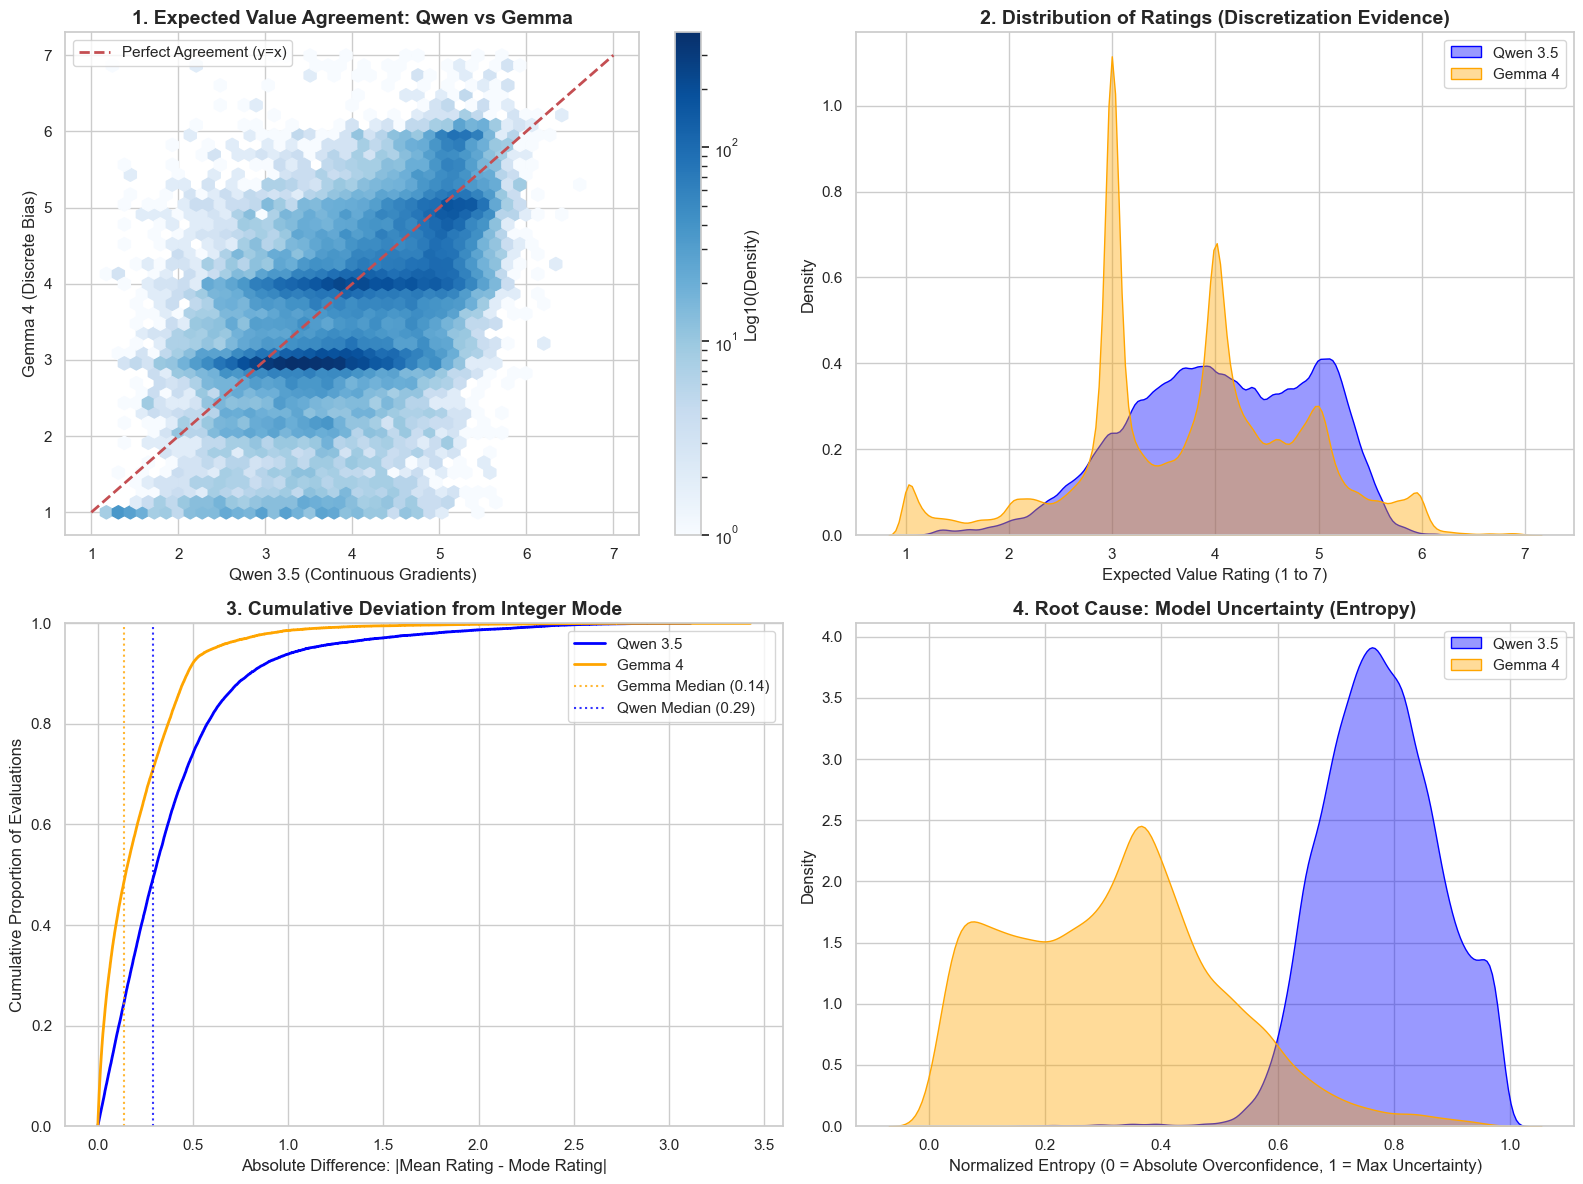

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- 🚀 VISUALIZING ARCHITECTURAL DIFFERENCES ---")

# 1. Merge for direct comparison
# (assuming you have input_id, dimension_name, mean_rating, mode_rating, and normalized_entropy in both dfs)
comp_df = pd.merge(
    qwen_df[['input_id', 'dimension_name', 'mean_rating',
             'mode_rating', 'normalized_entropy']],
    gemma_df[['input_id', 'dimension_name', 'mean_rating',
              'mode_rating', 'normalized_entropy']],
    on=['input_id', 'dimension_name'],
    suffixes=('_qwen', '_gemma')
)

# Set up the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------------------------------
# PLOT 1: Hexbin Density (Qwen vs Gemma Agreement)
# ---------------------------------------------------------
ax = axes[0, 0]
# Hexbin solves overplotting by showing the density of points
hb = ax.hexbin(comp_df['mean_rating_qwen'], comp_df['mean_rating_gemma'],
               gridsize=40, cmap='Blues', mincnt=1, bins='log')
# Line of perfect identity
ax.plot([1, 7], [1, 7], 'r--', lw=2, label='Perfect Agreement (y=x)')
ax.set_title("1. Expected Value Agreement: Qwen vs Gemma",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Qwen 3.5 (Continuous Gradients)")
ax.set_ylabel("Gemma 4 (Discrete Bias)")
ax.legend(loc='upper left')
fig.colorbar(hb, ax=ax, label='Log10(Density)')

# ---------------------------------------------------------
# PLOT 2: KDE of Mean Ratings (The "Spikiness")
# ---------------------------------------------------------
ax = axes[0, 1]
# A lower bw_adjust prevents seaborn from over-smoothing the integer spikes
sns.kdeplot(comp_df['mean_rating_qwen'], ax=ax, label='Qwen 3.5',
            fill=True, color='blue', bw_adjust=0.4, alpha=0.4)
sns.kdeplot(comp_df['mean_rating_gemma'], ax=ax, label='Gemma 4',
            fill=True, color='orange', bw_adjust=0.4, alpha=0.4)
ax.set_title("2. Distribution of Ratings (Discretization Evidence)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Expected Value Rating (1 to 7)")
ax.set_ylabel("Density")
ax.legend()

# ---------------------------------------------------------
# PLOT 3: ECDF of Absolute Deviation (Mean minus Mode)
# ---------------------------------------------------------
ax = axes[1, 0]
comp_df['dev_qwen'] = abs(
    comp_df['mean_rating_qwen'] - comp_df['mode_rating_qwen'])
comp_df['dev_gemma'] = abs(
    comp_df['mean_rating_gemma'] - comp_df['mode_rating_gemma'])

sns.ecdfplot(comp_df['dev_qwen'], ax=ax, label='Qwen 3.5', color='blue', lw=2)
sns.ecdfplot(comp_df['dev_gemma'], ax=ax,
             label='Gemma 4', color='orange', lw=2)
ax.set_title("3. Cumulative Deviation from Integer Mode",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Absolute Difference: |Mean Rating - Mode Rating|")
ax.set_ylabel("Cumulative Proportion of Evaluations")
# Mark the medians you found earlier
ax.axvline(0.14, color='orange', linestyle=':',
           alpha=0.8, label='Gemma Median (0.14)')
ax.axvline(0.29, color='blue', linestyle=':',
           alpha=0.8, label='Qwen Median (0.29)')
ax.legend()

# ---------------------------------------------------------
# PLOT 4: Entropy Distributions (The Root Cause)
# ---------------------------------------------------------
ax = axes[1, 1]
sns.kdeplot(comp_df['normalized_entropy_qwen'], ax=ax,
            label='Qwen 3.5', fill=True, color='blue', alpha=0.4)
sns.kdeplot(comp_df['normalized_entropy_gemma'], ax=ax,
            label='Gemma 4', fill=True, color='orange', alpha=0.4)
ax.set_title("4. Root Cause: Model Uncertainty (Entropy)",
             fontsize=14, fontweight='bold')
ax.set_xlabel(
    "Normalized Entropy (0 = Absolute Overconfidence, 1 = Max Uncertainty)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

--- 🚀 THE FAIR VARIANCE COMPARISON ---


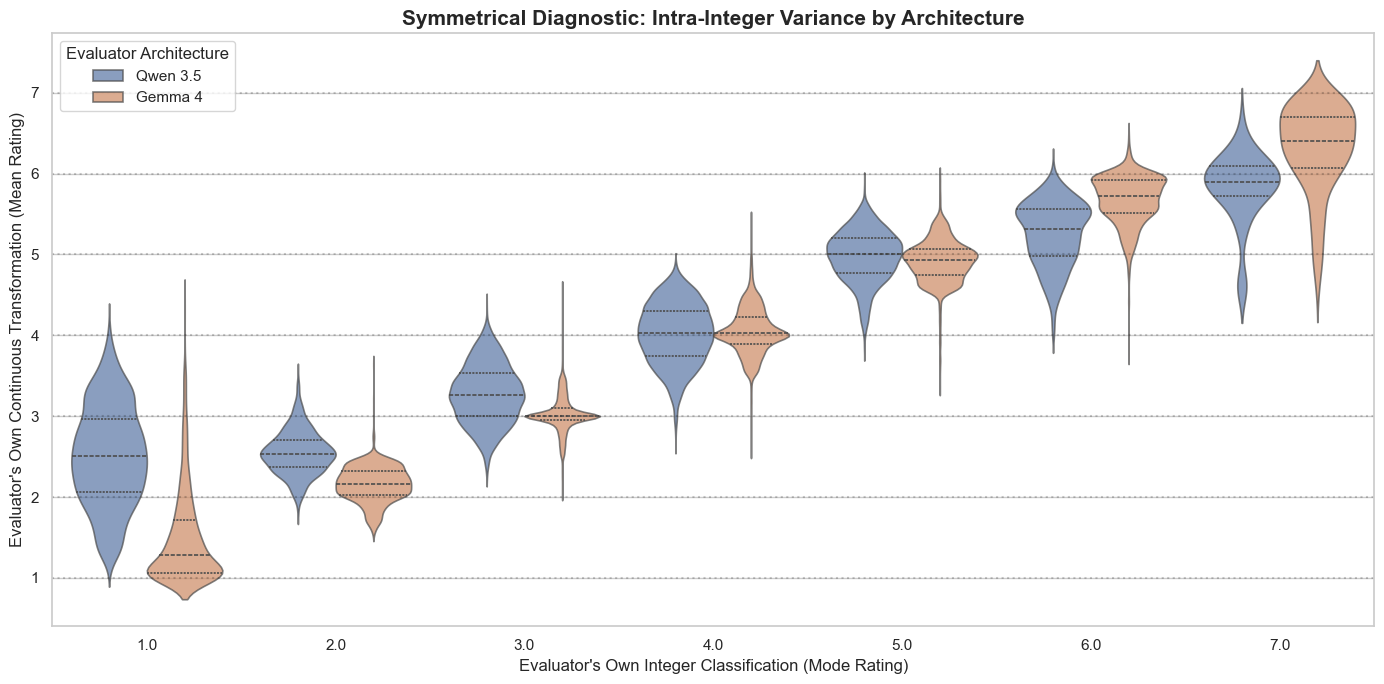

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 🚀 THE FAIR VARIANCE COMPARISON ---")

# 1. Structure the data for a side-by-side comparison
qwen_plot_df = comp_df[['mode_rating_qwen', 'mean_rating_qwen']].copy()
qwen_plot_df.columns = ['Mode_Rating', 'Mean_Rating']
qwen_plot_df['Model'] = 'Qwen 3.5'

gemma_plot_df = comp_df[['mode_rating_gemma', 'mean_rating_gemma']].copy()
gemma_plot_df.columns = ['Mode_Rating', 'Mean_Rating']
gemma_plot_df['Model'] = 'Gemma 4'

fair_plot_df = pd.concat([qwen_plot_df, gemma_plot_df])

# 2. Build the symmetrical plot
plt.figure(figsize=(14, 7))

# We use dodged violins to show them side-by-side per integer
sns.violinplot(
    data=fair_plot_df,
    x='Mode_Rating',
    y='Mean_Rating',
    hue='Model',
    inner='quartile',
    # Professional Blue/Orange
    palette={'Qwen 3.5': '#4C72B0', 'Gemma 4': '#DD8452'},
    density_norm='width',  # Ensures violins are equally wide for comparison
    linewidth=1.2,
    alpha=0.7
)

# Add a dashed line for perfect identity to show where the integer *should* be
for i in range(1, 8):
    plt.axhline(i, color='black', linestyle=':', alpha=0.2)

plt.title("Symmetrical Diagnostic: Intra-Integer Variance by Architecture",
          fontsize=15, fontweight='bold')
plt.xlabel("Evaluator's Own Integer Classification (Mode Rating)", fontsize=12)
plt.ylabel("Evaluator's Own Continuous Transformation (Mean Rating)", fontsize=12)
plt.legend(title='Evaluator Architecture', loc='upper left')
plt.tight_layout()
plt.show()

Figure X: Architectural Diagnostics of Evaluator Discretization
(Bottom Right, Plot 4): Gemma 4 exhibits severe overconfidence (logit spiking), clustering its entropy near zero, while Qwen 3.5 displays well-calibrated uncertainty.
(Bottom Left, Plot 3): Consequently, Gemma's overconfidence prevents the Expected Value transformation from shifting scores away from the integer mode, whereas Qwen utilizes the full continuous space.
(Top Right, Plot 2): This failure to escape the integer mode results in massive discretization spikes in Gemma's final rating distribution, destroying the continuous gradient.
(Top Left, Plot 1): As a result, when compared head-to-head, Gemma acts as a low-fidelity step-function (horizontal banding), failing to capture the subtle intra-integer economic gradients successfully mapped by Qwen 3.5.

#### Add 'workload volume' cutoff

In [54]:
# DEFINE VARIABLES
from IPython.display import display, clear_output
import ipywidgets as widgets
CONTENT_TYPE_COL = ['consolidated_categories', 'macro_category'][1]

CATEGORICALS = ['market_scope', CONTENT_TYPE_COL, 'year_week']
CATEGORICALS = ['market_scope', CONTENT_TYPE_COL, 'year_month']

# CATEGORICALS = ['market_scope', 'consolidated_categories', 'deal_type']


CONTINUOUS = ['competitor_density']
BINARIES = ['strict_follower_requirement']


# Experimental groups (required by your BaseRegressionRunner)
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']


# RUN MODEL

# 1. Create a copy of your balanced dataframe
mega_df = final_df_balanced.copy()

# prompts_to_include = ['16071a84cca9','5f7ea2deacb8', '26fac938d6ea', 'd39649b54a27']

# mega_df = mega_df[mega_df['prompt_id'].isin(prompts_to_include)]


# 2. Create a globally unique dimension name by concatenating the metadata
mega_df['dimension_name'] = (
    mega_df['model_name'] + "_" +
    mega_df['prompt_id'] + "_" +
    mega_df['dimension_name']
)


# --- 1. Extract and engineer the Workload Hurdle ---
WORKLOAD_DIM = 'Qwen/Qwen3.5-4B_d39649b54a27_creators_requirement_workload_volume'

# Isolate the workload rows
workload_df = mega_df[mega_df['dimension_name'] == WORKLOAD_DIM].copy()

# Create the binary hurdle using the superior continuous expected value (mean_rating)
# Threshold: If expected value >= 2.5, it's considered "High Friction"
workload_df['is_high_friction'] = (workload_df['mean_rating'] >= 3).astype(int)

# Map this back to the main balanced dataframe (before you filtered mega_df)
# Assuming 'id' or 'deal_id' is your unique row identifier
friction_mapping = workload_df.set_index('deal_id')['is_high_friction']
final_df_balanced['is_high_friction'] = final_df_balanced['deal_id'].map(
    friction_mapping).fillna(0)

# --- 2. Update your variable lists ---
# Add the new bucket to your standard binary controls
BINARIES = ['strict_follower_requirement', 'is_high_friction']

# --- 3. Clean up the mega_df for the widget ---
# Now recreate mega_df, but DROP the workload dimension from the LLM variables
# so the runner doesn't include it twice.
mega_df = final_df_balanced.copy()
prompts_to_include = ['d39649b54a27']  # Keep only your newest best prompt
mega_df = mega_df[mega_df['prompt_id'].isin(prompts_to_include)]
mega_df['dimension_name'] = mega_df['model_name'] + "_" + \
    mega_df['prompt_id'] + "_" + mega_df['dimension_name']
mega_df['mega_group'] = 'all_predictors'

# Drop the LLM workload row since we are now passing it natively in BINARIES
mega_df = mega_df[mega_df['dimension_name'] != WORKLOAD_DIM]


# 3. Create a single dummy group so the runner doesn't split the data
mega_df['mega_group'] = 'all_predictors'


# 1. Get all unique dimensions from your mega dataframe
all_variables = sorted(mega_df['dimension_name'].unique().tolist())

# 2. Create the interactive multi-select widget
variable_selector = widgets.SelectMultiple(
    options=all_variables,
    value=all_variables,  # Default selects all of them (Kitchen Sink)
    rows=15,
    description='Variables:',
    layout=widgets.Layout(width='80%')
)

run_button = widgets.Button(
    description='Run Custom Model',
    button_style='success',
    icon='play'
)

output_area = widgets.Output()


def run_custom_regression(b):
    with output_area:
        clear_output(wait=True)
        selected_vars = list(variable_selector.value)

        if not selected_vars:
            print("⚠️ Please select at least one variable.")
            return

        print(
            f"🚀 Running OLS with {len(selected_vars)} selected dimensions...\n")

        # CORE MECHANIC: Filter the long dataframe to ONLY include selected variables
        # When the runner pivots this, the excluded variables simply won't exist!
        filtered_df = mega_df[mega_df['dimension_name'].isin(
            selected_vars)].copy()

        # Re-initialize the runner
        custom_runner = create_regression_runner(
            target_col='apps_after_7_days',
            experimental_groups=['mega_group'],
            cluster_col='partner_id',
            model_type='negbin'
        )

        # Fit the model
        custom_runner.run_regression(
            df=filtered_df,
            cat_vars=CATEGORICALS,
            bin_vars=BINARIES,
            num_vars=CONTINUOUS,
            # predictor_name='mean_rating'
            predictor_name='mode_rating'

        )

        # Display the statsmodels summary table
        # The key is ('mega_group',) because of how groupby handles single-item lists

        # Safely attempt to fetch the result
        result = custom_runner.results.get("('all_predictors',)")

        if result is not None:
            print(result.summary())
        else:
            print("🚨 MODEL FAILED TO CONVERGE.")
            print("Check for Perfect Multicollinearity. One of your binary variables (like friction) is likely all 0s, or a category has 0 observations.")
        # result = custom_runner.results["('all_predictors',)"]
        # if result:
        #     print(result.summary())
        # else:
        #     print("🚨 Model failed to converge. Check your variable mix.")


# 3. Render the UI
run_button.on_click(run_custom_regression)
display(variable_selector, run_button, output_area)

SelectMultiple(description='Variables:', layout=Layout(width='80%'), options=(), rows=15, value=())

Button(button_style='success', description='Run Custom Model', icon='play', style=ButtonStyle())

Output()

## EDA

### dsfasdf

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_23184\1655447779.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sorted_logits'] = df['sorted_logits'].apply(


✅ Descriptives saved to 'llm_psychometric_descriptives.csv'
       prompt_id                                 dimension_name  expected_std  \
6   f162d59256cc      deal_pitch_formative_product_universality      1.373176   
1   f162d59256cc   deal_pitch_formative_call_to_action_strength      1.330035   
4   f162d59256cc        deal_pitch_formative_functional_utility      1.322642   
5   f162d59256cc  deal_pitch_formative_perceived_economic_value      1.169666   
9   f162d59256cc           deal_pitch_formative_workload_volume      1.168730   
3   f162d59256cc   deal_pitch_formative_creator_brand_alignment      1.164814   
0   f162d59256cc            deal_pitch_formative_brand_prestige      1.153886   
26  f162d59256cc      deal_pitch_formative_product_universality      1.122890   
24  f162d59256cc        deal_pitch_formative_functional_utility      1.096639   
28  f162d59256cc        deal_pitch_formative_rhetorical_realism      1.024470   
22  f162d59256cc  deal_pitch_formative_creative_r

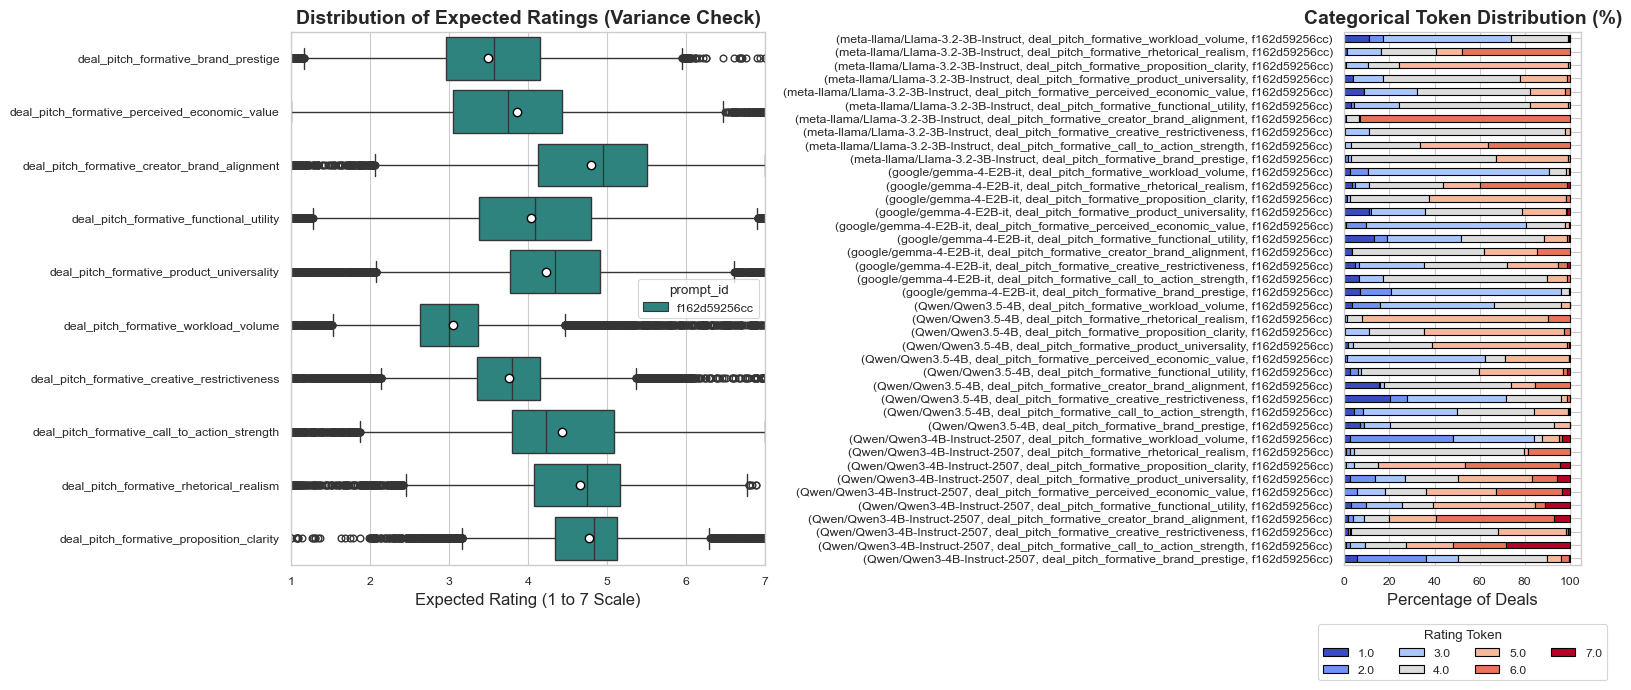

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

eda_df = final_df[final_df['model_name'] == 'Qwen/Qwen3.5-4B']
eda_df = final_df[final_df['prompt_id'] == 'f162d59256cc']

# eda_df = final_df[final_df['prompt_id'].isin(['722bbd35b498', '1dd96c436d00'])]
# eda_df = eda_df[eda_df['model_name'] == 'google/gemma-4-E2B-it']


def generate_llm_eda(df):
    """
    Generates EDA for LLM logit outputs, focusing on variance and entropy.
    """
    # 1. Clean the sorted_logits if they are stored as strings (common when reading from CSV)
    if isinstance(df['sorted_logits'].iloc[0], str):
        df['sorted_logits'] = df['sorted_logits'].apply(ast.literal_eval)

    # Flatten the nested lists if they are [[a, b, c, d]] -> [a, b, c, d]
    df['sorted_logits'] = df['sorted_logits'].apply(
        lambda x: x[0] if isinstance(x[0], list) else x)

    # 2. Descriptive Statistics Table
    group_cols = ['model_name', 'prompt_id', 'dimension_name']

    # We want to see if the model has variance (std) and how confident it is (entropy)
    descriptives = df.groupby(group_cols).agg(
        n_obs=('mode_rating', 'count'),

        # Mode Rating Descriptives
        mode_mean=('mode_rating', 'mean'),
        mode_std=('mode_rating', 'std'),

        # Mean Rating (Softmax) Descriptives
        expected_mean=('mean_rating', 'mean'),
        expected_std=('mean_rating', 'std'),

        # Entropy (Uncertainty)
        entropy_mean=('normalized_entropy', 'mean'),
        entropy_std=('normalized_entropy', 'std')
    ).reset_index()

    # Sort by standard deviation to easily spot zero-variance dimensions
    descriptives = descriptives.sort_values(by='expected_std', ascending=False)

    # Save the table for your thesis appendix
    descriptives.to_csv("llm_psychometric_descriptives.csv", index=False)
    print("✅ Descriptives saved to 'llm_psychometric_descriptives.csv'")
    print(descriptives[['prompt_id', 'dimension_name',
          'expected_std', 'entropy_mean']])

    # 3. Visualization: The Variance & Distribution Plot
    sns.set_theme(style="whitegrid", context="paper")

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(
        16, 7), gridspec_kw={'width_ratios': [2, 1]})

    # Plot A: Boxplot of Mean Ratings to show variance per dimension
    sns.boxplot(
        data=df,
        y='dimension_name',
        x='mean_rating',
        hue='prompt_id',
        ax=axes[0],
        palette="viridis",
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "white",
                   "markeredgecolor": "black"}
    )
    axes[0].set_title(
        'Distribution of Expected Ratings (Variance Check)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Expected Rating (1 to 7 Scale)', fontsize=12)
    axes[0].set_ylabel('')
    axes[0].set_xlim(1, 7)

    # Plot B: Stacked Bar Chart for the 1-4 Token Distribution (Mode)
    mode_counts = df.groupby(
        ['model_name', 'dimension_name', 'prompt_id', 'mode_rating']).size().unstack(fill_value=0)
    # Normalize to percentages
    mode_pct = mode_counts.div(mode_counts.sum(axis=1), axis=0) * 100

    mode_pct.plot(
        kind='barh',
        stacked=True,
        colormap='coolwarm',
        ax=axes[1],
        edgecolor='black'
    )
    axes[1].set_title('Categorical Token Distribution (%)',
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Percentage of Deals', fontsize=12)
    axes[1].set_ylabel('')
    axes[1].legend(title="Rating Token", loc='upper center',
                   bbox_to_anchor=(0.5, -0.1), ncol=4)

    plt.tight_layout()
    plt.savefig("llm_evaluation_distribution.png",
                dpi=300, bbox_inches='tight')
    plt.show()


# Run the function on your dataframe:
generate_llm_eda(eda_df)

In [56]:
print(final_df[final_df['prompt_id'] == 'd39649b54a27'].groupby(
    ['model_name', 'prompt_id', 'dimension_name', 'mode_rating'])['normalized_entropy'].mean())

Series([], Name: normalized_entropy, dtype: float64)


In [57]:
final_df[['model_name', 'prompt_id', 'dimension_name', 'deal_title',
          'deal_text', 'mean_rating', 'mode_rating', 'normalized_entropy']]

,model_name,prompt_id,dimension_name,deal_title,deal_text,mean_rating,mode_rating,normalized_entropy
0,google/gemma-4-E2B-it,698a82f5d8a3,deal_pitch_holistic_reward_attractiveness,Best Collagen Shot with Longevity capsules,Our innovative formula combines an effective b...,3.945856,4.0,0.116823
1,google/gemma-4-E2B-it,698a82f5d8a3,deal_pitch_holistic_burden_acceptability,Best Collagen Shot with Longevity capsules,Our innovative formula combines an effective b...,4.227052,4.0,0.328518
2,google/gemma-4-E2B-it,698a82f5d8a3,deal_pitch_holistic_pitch_professionalism,Best Collagen Shot with Longevity capsules,Our innovative formula combines an effective b...,3.256817,3.0,0.350134
3,google/gemma-4-E2B-it,6faa8a8b031c,deal_pitch_holistic_deal_attractiveness,Best Collagen Shot with Longevity capsules,Our innovative formula combines an effective b...,3.981102,4.0,0.053217
4,google/gemma-4-E2B-it,f162d59256cc,deal_pitch_formative_brand_prestige,Best Collagen Shot with Longevity capsules,Our innovative formula combines an effective b...,3.047336,3.0,0.106843
...,...,...,...,...,...,...,...,...
175051,Qwen/Qwen3.5-4B,f162d59256cc,deal_pitch_formative_workload_volume,🍔 Etentje voor 2 bij Le Smash (t.w.v. €65),<p><span>Le&nbsp;Smash&nbsp;in</span><strong>&...,2.654812,3.0,0.659895
175052,Qwen/Qwen3.5-4B,f162d59256cc,deal_pitch_formative_creative_restrictiveness,🍔 Etentje voor 2 bij Le Smash (t.w.v. €65),<p><span>Le&nbsp;Smash&nbsp;in</span><strong>&...,2.500376,3.0,0.702611
175053,Qwen/Qwen3.5-4B,f162d59256cc,deal_pitch_formative_call_to_action_strength,🍔 Etentje voor 2 bij Le Smash (t.w.v. €65),<p><span>Le&nbsp;Smash&nbsp;in</span><strong>&...,4.091025,4.0,0.891458
175054,Qwen/Qwen3.5-4B,f162d59256cc,deal_pitch_formative_rhetorical_realism,🍔 Etentje voor 2 bij Le Smash (t.w.v. €65),<p><span>Le&nbsp;Smash&nbsp;in</span><strong>&...,5.005986,5.0,0.737758


In [58]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd


def create_dataframe_inspector(df):
    # 1. Get unique dimensions for the dropdown
    unique_dimensions = sorted(df['dimension_name'].unique().tolist())

    # 2. Create Widgets
    dim_selector = widgets.Dropdown(
        options=unique_dimensions,
        description='Dimension:',
        layout=widgets.Layout(width='60%')
    )

    rating_selector = widgets.Dropdown(
        options=[1.0, 2.0, 3.0, 4.0],
        description='Mode Rating:',
        layout=widgets.Layout(width='30%')
    )

    output_area = widgets.Output()

    # 3. The display function
    def update_view(change=None):
        with output_area:
            clear_output(wait=True)
            selected_dim = dim_selector.value
            selected_rating = rating_selector.value

            # Filter the dataframe
            mask = (df['dimension_name'] == selected_dim) & (
                df['mode_rating'] == selected_rating)
            filtered_df = df[mask].copy()

            total_matches = len(filtered_df)
            print(
                f"📊 Found {total_matches} deals for '{selected_dim}' rated as {selected_rating}\n")

            if total_matches == 0:
                return

            # Define which columns to show for clean analysis
            display_cols = ['deal_title', 'deal_text',
                            'mean_rating', 'normalized_entropy']
            # Only include columns that actually exist in the dataframe to prevent KeyError
            display_cols = [
                c for c in display_cols if c in filtered_df.columns]

            # Sort: If it's a 4, show the highest probabilities first. If it's a 1, show the lowest probabilities first.
            ascending_sort = True if selected_rating <= 2.0 else False
            filtered_df = filtered_df.sort_values(
                by='mean_rating', ascending=ascending_sort)

            # Use native Jupyter display formatting
            display(filtered_df[display_cols].head(50))

    # 4. Bind the observers to the widgets
    dim_selector.observe(update_view, names='value')
    rating_selector.observe(update_view, names='value')

    # 5. Display UI and initialize the first view
    ui = widgets.HBox([dim_selector, rating_selector])
    display(ui, output_area)
    update_view()


# Run it by passing your LLM dataframe:
create_dataframe_inspector(mega_df)

Output()

In [59]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
from itables import show


def create_dataframe_inspector(df):
    unique_dimensions = sorted(df['dimension_name'].unique().tolist())

    dim_selector = widgets.Dropdown(
        options=unique_dimensions,
        description='Dimension:',
        layout=widgets.Layout(width='60%')
    )

    rating_selector = widgets.Dropdown(
        options=[1.0, 2.0, 3.0, 4.0],
        description='Mode Rating:',
        layout=widgets.Layout(width='30%')
    )

    output_area = widgets.Output()

    def update_view(change=None):
        with output_area:
            clear_output(wait=True)
            selected_dim = dim_selector.value
            selected_rating = rating_selector.value

            mask = (df['dimension_name'] == selected_dim) & (
                df['mode_rating'] == selected_rating)
            filtered_df = df[mask].copy()

            total_matches = len(filtered_df)
            print(
                f"📊 Found {total_matches} deals for '{selected_dim}' rated as {selected_rating}\n")

            if total_matches == 0:
                return

            display_cols = ['deal_title', 'deal_text',
                            'mean_rating', 'normalized_entropy']
            display_cols = [
                c for c in display_cols if c in filtered_df.columns]

            ascending_sort = selected_rating <= 2.0
            filtered_df = filtered_df.sort_values(
                by='mean_rating', ascending=ascending_sort)

            # ✅ This forces the rich interactive pandas output
            show(filtered_df[display_cols].head(50))

    dim_selector.observe(update_view, names='value')
    rating_selector.observe(update_view, names='value')

    ui = widgets.HBox([dim_selector, rating_selector])
    display(ui, output_area)
    update_view()


create_dataframe_inspector(mega_df)

Output()

# Raw df

Goal
- Determine which (subjective) textual characteristics make some deals garner more applications than others
    - Specific focus on mutable characteristics: that which we can change about the text

In [38]:
import pandas as pd
import numpy as np
import src.paths

In [39]:
df_deals = pd.read_parquet(
    src.paths.PROCESSED_DATA_DIR / "BARTER_DEALS_MODEL_READY.parquet")

## Analyse most/least application deals

- most applications

In [40]:
df_deals.sort_values('apps_after_7_days', ascending=False)[
    ['deal_title', 'deal_text', 'legacy_partner_id', 'apps_after_7_days']]

,deal_title,deal_text,legacy_partner_id,apps_after_7_days
6803,🇮🇹3-Day Truffle & Wine Experience in Italy €1750,<p><strong>Important:&nbsp;we&nbsp;can&nbsp;pl...,NaN,265
6435,Robotstofzuiger SMART met Dweilfunctie en Laad...,<p><strong>De&nbsp;Earkings&nbsp;Robotstofzuig...,NaN,238
6585,"Show off our beautiful, comfi and sexy pajamas. 😍",<p>We&nbsp;are&nbsp;offering&nbsp;3&nbsp;sets&...,NaN,183
5442,Content creator,1. Een vaste vergoeding van €500 per maand (na...,2894.0,182
5265,Unbox Verloren & Retour Postpakketten t.w.v. €...,Een XL doos met verloren & retour postpakkette...,2910.0,177
...,...,...,...,...
3748,"Kom langs bij Woarst, ontvang lunch + winkelte...",Jij komt langs bij Woarst in Arnhem – de lekke...,1875.0,0
3728,Summer Collab: Rechargeable Garden Light,Suspension Positano de New Garden avec source ...,1562.0,0
3701,Mach auch du die Betten sicherer,Du bekommst von mir im Gegenzug Ware im Wert v...,1772.0,0
3113,Huidverstrakking 2.0,Krijg met deze nieuwste trend een strakke mooi...,1593.0,0


- least applications

In [41]:
df_deals.sort_values('apps_after_7_days', ascending=True)[
    ['deal_title', 'deal_text', 'apps_after_7_days', 'applicants_applications_count']]

,deal_title,deal_text,apps_after_7_days,applicants_applications_count
3113,Huidverstrakking 2.0,Krijg met deze nieuwste trend een strakke mooi...,0,3
3149,Nasal Strip testers,We are looking for German product testers!\nWo...,0,10
5720,Create 3 product review videos of our jewellery,We’re offering 3 pieces of our handcrafted jew...,0,2
5493,MOBVOI TicNote KI Sprachrekorder mit App,Mobvoi TicNote - Der smarte KI-Sprachrekorder ...,0,0
5466,Gourmetten tijdens de feestdagen,Het Kerst Gourmet menu van A-Z Gourmet Service...,0,10
...,...,...,...,...
5265,Unbox Verloren & Retour Postpakketten t.w.v. €...,Een XL doos met verloren & retour postpakkette...,177,493
5442,Content creator,1. Een vaste vergoeding van €500 per maand (na...,182,436
6585,"Show off our beautiful, comfi and sexy pajamas. 😍",<p>We&nbsp;are&nbsp;offering&nbsp;3&nbsp;sets&...,183,192
6435,Robotstofzuiger SMART met Dweilfunctie en Laad...,<p><strong>De&nbsp;Earkings&nbsp;Robotstofzuig...,238,416


- NLD only

In [42]:
mask = df_deals['accepted_countries'].apply(lambda x: 'NLD' in x)
df_deals_nl = df_deals[mask]
df_deals_nl = df_deals_nl[df_deals_nl['deal_type'] == 'online']
a = df_deals_nl.sort_values('apps_after_7_days')[['deal_title', 'deal_text', 'apps_after_7_days',
                                                  'applicants_applications_count']]

a

,deal_title,deal_text,apps_after_7_days,applicants_applications_count
3188,Een unieke nieuwe natuurlijke hondenshampoo,"Een pakket met de Hondenshampoo, de Reinigings...",0,7
4159,Awareness: Schrijven met de Hand | Correctbook,In aanloop naar de Week van Lezen en Schrijven...,0,6
3966,Luxe Tuinverlichting (t.w.v. €200),Je ontvangt één of meerdere armaturen van Ligh...,0,5
5466,Gourmetten tijdens de feestdagen,Het Kerst Gourmet menu van A-Z Gourmet Service...,0,10
5996,Hoe oerpaniek je relatie beïnvloed,Voel je soms dat kleine irritaties plotseling ...,0,0
...,...,...,...,...
5919,Creëer jouw ultieme wellness moment met Rituals,Wij bieden de Rituals The Ritual of Karma Tria...,177,473
5442,Content creator,1. Een vaste vergoeding van €500 per maand (na...,182,436
6585,"Show off our beautiful, comfi and sexy pajamas. 😍",<p>We&nbsp;are&nbsp;offering&nbsp;3&nbsp;sets&...,183,192
6435,Robotstofzuiger SMART met Dweilfunctie en Laad...,<p><strong>De&nbsp;Earkings&nbsp;Robotstofzuig...,238,416


# Deals w/ ratings

In [ ]:
# Setup
import yaml
from src.general_analysis.engine import AnalysisEnvironment

import pandas as pd
import numpy as np
import statsmodels.api as sm

In [44]:
env = AnalysisEnvironment(active_analysis='barter_deals')

# Load everything
final_df, og_df = env.load_data()
pm, prompt_map = env.load_prompts(prompt_subfolder='sandbox/BARTER_DEALS')

Loading files for analysis barter_deals
🐢 Running full processing pipeline...
Results dir: C:\Users\Wouter Barter\Documents\AI_thesis\results\sandbox\BARTER_DEALS
input_data_path: C:\Users\Wouter Barter\Documents\AI_thesis\data\processed\BARTER_DEALS_MODEL_READY.parquet
Loading evaluations...
⚠️ Skipping arch_temp: No .pt files found in C:\Users\Wouter Barter\Documents\AI_thesis\results\sandbox\BARTER_DEALS\arch_temp


KeyboardInterrupt: 

# REST

In [ ]:
# Check the new distribution
print(df_deals['macro_category'].value_counts())

KeyError: 'macro_category'

In [ ]:
df_deals[df_deals['content_types_clean'] == {
    'Lifestyle', 'Tech'}][['deal_text', 'deal_type']]

,deal_text,deal_type
3211,The Calex Smart Indoor IP Camera offers unbeat...,online
3696,We schenken één volledig ‘Jouw Portfolio’-pakk...,online
3791,Wir stellen dir mehrere Lochwände zur Verfügun...,online
4139,Erhalte kostenlos die Tristan Auron Schallzahn...,online
4426,Ontvang de Flystopper 300: een krachtige vlieg...,online
4531,Otiume.nl is een merk gespecialiseerd in stijl...,online
5136,Je ontvangt een Swiftvein Solara wake-up light.,online
5678,"In exchange, you will receive a high-quality h...",online
5834,<p>Ontvang&nbsp;3&nbsp;maanden&nbsp;gratis&nbs...,physical
6405,<p>You&nbsp;receive&nbsp;€300&nbsp;in&nbsp;cre...,online


In [ ]:
df_deals[df_deals['macro_category'] ==
         'Uncategorized'][['deal_text', 'deal_type']]

,deal_text,deal_type
3111,A box of our best sellers gummies worth of €150,online
3112,The tastiest and healthiest matcha gummies.,online
3117,We leveren een bouwlamp op zonen energie in de...,online
3118,We leveren een foam roller set met als tegenpr...,online
3204,We leveren een pilates board in de kleur Roze ...,online
3205,We leveren een jaloezie reiniger in de kleur B...,online
3206,We leveren een Nekmassage Apparaat Met als teg...,online
3450,<p>Get&nbsp;50&nbsp;Custom&nbsp;Newspapers&nbs...,online
3459,<p>Run&nbsp;a&nbsp;custom&nbsp;newspaper&nbsp;...,online
3461,<p>Create&nbsp;a&nbsp;custom&nbsp;photo&nbsp;b...,online


In [ ]:
df_deals[df_deals.content_types_clean.isna()]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,log_deal_value,log_online_active_0_7d,log_online_active_7_30d,log_phys_active_0_7d_0_20km,log_phys_active_0_7d_20_50km,log_phys_active_7_30d_0_20km,log_phys_active_7_30d_20_50km,log_global_active_0_7d,log_global_active_7_30d,content_types_clean
3111,28,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019697d1-44ec-00c8-7c86-d799cad44ba2,uploads/deals/019697d0-ac12-ffff-0985-b6cc1090...,1500,None,2025-05-03 20:23:16.585465,2025-05-04 08:21:19.876144,2025-09-19 13:39:51.631259,None,...,5.017280,5.929589,6.626718,0.0,0.0,0.0,0.0,5.924256,6.678342,NaN
3112,47,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019697dd-cc29-00c8-16f0-d20d216883f7,uploads/deals/019697dd-98ac-ffff-4612-efd86a94...,1500,None,2025-05-03 20:36:57.612548,2025-05-04 06:29:24.175618,2025-09-19 13:38:40.049701,None,...,3.713572,5.929589,6.626718,0.0,0.0,0.0,0.0,5.924256,6.678342,NaN
3117,4,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",01969fe6-8873-00c8-ead9-401fd92a3133,uploads/deals/01969fe5-0a4f-ffff-fbd9-b63847ce...,5000,None,2025-05-05 10:03:27.884309,2025-05-05 14:08:57.402484,2025-05-08 18:25:15.218212,None,...,0.000000,5.616771,6.282267,0.0,0.0,0.0,0.0,5.971262,6.654153,NaN
3118,3,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",01969fee-f829-00c8-01a1-e63d1e76ec05,uploads/deals/01969fee-8be1-ffff-40e3-d6cd62b0...,5000,None,2025-05-05 10:12:40.797804,2025-05-05 14:09:12.636788,2025-05-06 12:43:55.695511,None,...,0.000000,5.616771,6.282267,0.0,0.0,0.0,0.0,5.971262,6.654153,NaN
3204,13,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",0196b5d4-e21d-00c8-ccf1-48fed42976b9,uploads/deals/0196b5d3-c91b-ffff-6d94-623709dc...,10000,None,2025-05-09 16:15:50.049109,2025-05-09 17:05:34.975912,2025-05-15 16:41:08.445603,None,...,0.000000,5.153292,5.886104,0.0,0.0,0.0,0.0,5.966147,6.673298,NaN
3205,3,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",0196b5da-8488-00c8-a684-82c19005e799,uploads/deals/0196b5d9-46b2-ffff-18dc-b411e412...,5000,None,2025-05-09 16:21:59.174906,2025-05-09 20:14:42.736404,2025-05-14 12:23:31.489040,None,...,0.000000,5.620401,6.295266,0.0,0.0,0.0,0.0,5.966147,6.673298,NaN
3206,9,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",0196b5df-6fa6-00c8-6bf8-f2bc47963d7f,uploads/deals/0196b5df-4650-ffff-1429-8070ffa9...,5000,None,2025-05-09 16:27:21.538118,2025-05-09 16:42:47.081492,2025-05-14 10:13:49.611355,None,...,0.000000,5.620401,6.295266,0.0,0.0,0.0,0.0,5.966147,6.673298,NaN
3450,149,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",0197124c-1a05-00c8-9be4-a02057ce0939,uploads/deals/0197163e-38d6-ffff-35c5-2c0b357d...,1500,None,2025-05-28 08:09:13.007276,2025-05-28 08:16:28.006209,2026-02-19 09:50:08.794945,None,...,4.795791,6.073045,6.570883,0.0,0.0,0.0,0.0,6.066108,6.595781,NaN
3459,45,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019715f7-4b74-00c8-5312-641373a94b95,uploads/deals/019c294d-d402-ffff-c242-aef3a752...,1500,None,2025-05-28 09:02:00.714332,2025-05-28 09:05:56.025337,2026-03-23 15:22:26.067607,None,...,4.718499,6.066108,6.569481,0.0,0.0,0.0,0.0,6.095825,6.598509,NaN
3461,246,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019715fc-cebb-00c8-3e20-deabbb3e3ec0,uploads/deals/01971630-56d8-ffff-c416-2a459687...,1500,None,2025-05-28 09:20:29.777816,2025-05-28 09:56:21.675714,2026-03-21 10:07:15.343069,None,...,4.948760,6.066108,6.569481,0.0,0.0,0.0,0.0,6.095825,6.598509,NaN


In [ ]:
df_deals.content_types_clean.value_counts(dropna=False)

content_types_clean
{Beauty}                                                                  181
{Fashion}                                                                 156
{Lifestyle}                                                               120
{Food}                                                                     86
{Mom}                                                                      80
                                                                         ... 
{Mom, Movie, Entertainment}                                                 1
{Lifestyle, Cooking, Luxury, Drinks, Entertainment, Food}                   1
{Lifestyle, Cooking, Luxury, Drinks, Experiences, Entertainment, Food}      1
{Lifestyle, Cooking, Luxury, Entertainment, Food}                           1
{Sport, Cars, Fashion, Activities}                                          1
Name: count, Length: 913, dtype: int64

In [ ]:
df_deals[df_deals['content_types_set'] == {'UGC'}]['deal_text']

3111      A box of our best sellers gummies worth of €150
3112          The tastiest and healthiest matcha gummies.
3117    We leveren een bouwlamp op zonen energie in de...
3118    We leveren een foam roller set met als tegenpr...
3204    We leveren een pilates board in de kleur Roze ...
3205    We leveren een jaloezie reiniger in de kleur B...
3206    We leveren een Nekmassage Apparaat Met als teg...
3450    <p>Get&nbsp;50&nbsp;Custom&nbsp;Newspapers&nbs...
3459    <p>Run&nbsp;a&nbsp;custom&nbsp;newspaper&nbsp;...
3461    <p>Create&nbsp;a&nbsp;custom&nbsp;photo&nbsp;b...
3495    We're FireFighterBag.com, creators of bold, fu...
3712    We're looking for UGC creators who'd like to t...
3731    We’re Belter Prints — a rebellious UK-based wa...
3759    Wir bieten Influencern unser neues Schweißnaht...
3761    Wir schicken dir kostenlos unseren Schwanheime...
3812    Wir schicken dir kostenlos unseren beliebten S...
3908    Product - DIY/Home improvement - Owatrol Polyt...
3951    Du bek

In [ ]:
df_deals['content_types_set'] = df_deals['content_types_set'].apply(set)

In [ ]:
df_deals['content_types_set'].value_counts()

content_types_set
{Beauty}                                           154
{Fashion}                                          151
{Food}                                              79
{Lifestyle}                                         73
{UGC}                                               55
                                                  ... 
{Sport, Gaming, UGC, Entertainment, Activities}      1
{Nightlife, Drinks, Experiences, Entertainment}      1
{Travel, Experiences, Entertainment, Food}           1
{Vegan, Drinks, Experiences, Food}                   1
{Vegan, Lifestyle, Drinks}                           1
Name: count, Length: 1063, dtype: int64

In [ ]:
print(df_deals['content_types_set'].count())

3126


In [ ]:
a = set(df_deals['content_types_set'].explode())

In [ ]:
df_deals['content_types_set'].explode().value_counts()

content_types_set
Lifestyle        1456
UGC              1097
Beauty            773
Fashion           699
Activities        663
Food              645
Luxury            620
Mom               599
Experiences       580
Drinks            454
Entertainment     397
Sport             371
Cooking           350
Vegan             349
Travel            314
Tech              278
Photography       198
Nightlife         169
Animals           136
Gaming            100
Cars               93
Music              93
Finance            83
Movie              45
Name: count, dtype: int64

## Analyse most/least application deals

- most applications

In [ ]:
df_deals.sort_values('apps_after_7_days', ascending=False)[
    ['deal_title', 'deal_text', 'legacy_partner_id', 'apps_after_7_days']]

,deal_title,deal_text,legacy_partner_id,apps_after_7_days
6803,🇮🇹3-Day Truffle & Wine Experience in Italy €1750,<p><strong>Important:&nbsp;we&nbsp;can&nbsp;pl...,NaN,265
6435,Robotstofzuiger SMART met Dweilfunctie en Laad...,<p><strong>De&nbsp;Earkings&nbsp;Robotstofzuig...,NaN,238
6585,"Show off our beautiful, comfi and sexy pajamas. 😍",<p>We&nbsp;are&nbsp;offering&nbsp;3&nbsp;sets&...,NaN,183
5442,Content creator,1. Een vaste vergoeding van €500 per maand (na...,2894.0,182
5265,Unbox Verloren & Retour Postpakketten t.w.v. €...,Een XL doos met verloren & retour postpakkette...,2910.0,177
...,...,...,...,...
3748,"Kom langs bij Woarst, ontvang lunch + winkelte...",Jij komt langs bij Woarst in Arnhem – de lekke...,1875.0,0
3728,Summer Collab: Rechargeable Garden Light,Suspension Positano de New Garden avec source ...,1562.0,0
3701,Mach auch du die Betten sicherer,Du bekommst von mir im Gegenzug Ware im Wert v...,1772.0,0
3113,Huidverstrakking 2.0,Krijg met deze nieuwste trend een strakke mooi...,1593.0,0


- least applications

In [ ]:
df_deals.sort_values('apps_after_7_days', ascending=True)[
    ['deal_title', 'deal_text', 'apps_after_7_days', 'applicants_applications_count']]

,deal_title,deal_text,apps_after_7_days,applicants_applications_count
3113,Huidverstrakking 2.0,Krijg met deze nieuwste trend een strakke mooi...,0,3
3149,Nasal Strip testers,We are looking for German product testers!\nWo...,0,10
5720,Create 3 product review videos of our jewellery,We’re offering 3 pieces of our handcrafted jew...,0,2
5493,MOBVOI TicNote KI Sprachrekorder mit App,Mobvoi TicNote - Der smarte KI-Sprachrekorder ...,0,0
5466,Gourmetten tijdens de feestdagen,Het Kerst Gourmet menu van A-Z Gourmet Service...,0,10
...,...,...,...,...
5265,Unbox Verloren & Retour Postpakketten t.w.v. €...,Een XL doos met verloren & retour postpakkette...,177,493
5442,Content creator,1. Een vaste vergoeding van €500 per maand (na...,182,436
6585,"Show off our beautiful, comfi and sexy pajamas. 😍",<p>We&nbsp;are&nbsp;offering&nbsp;3&nbsp;sets&...,183,192
6435,Robotstofzuiger SMART met Dweilfunctie en Laad...,<p><strong>De&nbsp;Earkings&nbsp;Robotstofzuig...,238,416


- NLD only

In [ ]:
mask = df_deals['accepted_countries'].apply(lambda x: 'NLD' in x)
df_deals_nl = df_deals[mask]
df_deals_nl = df_deals_nl[df_deals_nl['deal_type'] == 'online']
a = df_deals_nl.sort_values('apps_after_7_days')[['deal_title', 'deal_text', 'apps_after_7_days',
                                                  'applicants_applications_count']]

a

,deal_title,deal_text,apps_after_7_days,applicants_applications_count
3188,Een unieke nieuwe natuurlijke hondenshampoo,"Een pakket met de Hondenshampoo, de Reinigings...",0,7
4159,Awareness: Schrijven met de Hand | Correctbook,In aanloop naar de Week van Lezen en Schrijven...,0,6
3966,Luxe Tuinverlichting (t.w.v. €200),Je ontvangt één of meerdere armaturen van Ligh...,0,5
5466,Gourmetten tijdens de feestdagen,Het Kerst Gourmet menu van A-Z Gourmet Service...,0,10
5996,Hoe oerpaniek je relatie beïnvloed,Voel je soms dat kleine irritaties plotseling ...,0,0
...,...,...,...,...
5919,Creëer jouw ultieme wellness moment met Rituals,Wij bieden de Rituals The Ritual of Karma Tria...,177,473
5442,Content creator,1. Een vaste vergoeding van €500 per maand (na...,182,436
6585,"Show off our beautiful, comfi and sexy pajamas. 😍",<p>We&nbsp;are&nbsp;offering&nbsp;3&nbsp;sets&...,183,192
6435,Robotstofzuiger SMART met Dweilfunctie en Laad...,<p><strong>De&nbsp;Earkings&nbsp;Robotstofzuig...,238,416


# Deals w/ ratings

In [ ]:
# Setup
import yaml
from src.general_analysis.engine import AnalysisEnvironment

import pandas as pd
import numpy as np
import statsmodels.api as sm

In [ ]:
env = AnalysisEnvironment(active_analysis='barter_deals')

# Load everything
final_df, og_df = env.load_data()
pm, prompt_map = env.load_prompts(prompt_subfolder='sandbox/BARTER_DEALS')